# **Mini-Projet : Détection du Sarcasme dans les Tweets**

L’objectif du mini-projet est de construire un système capable de détecter automatiquement si un tweet est sarcastique ou non.
Pour cela, nous avons appliqué des techniques de 
**Machine Learning**
 traditionnel (Régression Logistique - SVM - Random Forest - Naive Bayes - K-Nearest Neighbors (KNN)) et de 
 **Deep Learning** (LSTM - BERT)

# Sommaire
* 1. Exploration et Analyse des Données (EAD)
* 2. Prétraitement du texte

**Partie Machine Learning**
* 3. Vectorisation (transformation en nombres)
* 4. Application d'algorithmes de Machine Learning
* 5. Comparaison et sélection du meilleur modèle
* 6. Test final et sauvegarde

**Partie Deep Learning**

* 3. Application d'algorithmes de Deep Learning
* 4. Comparaison et sélection du meilleur modèle
* 5. Test final et sauvegarde



## 1. Exploration et Analyse des Données (EAD)

In [77]:
import pandas as pd 
df=pd.read_csv("train.En.csv")
df.head()

,Unnamed: 0,tweet,sarcastic,rephrase,sarcasm,irony,satire,understatement,overstatement,rhetorical_question
0,0,The only thing I got from college is a caffein...,1,"College is really difficult, expensive, tiring...",0.0,1.0,0.0,0.0,0.0,0.0
1,1,I love it when professors draw a big question ...,1,I do not like when professors don’t write out ...,1.0,0.0,0.0,0.0,0.0,0.0
2,2,Remember the hundred emails from companies whe...,1,"I, at the bare minimum, wish companies actuall...",0.0,1.0,0.0,0.0,0.0,0.0
3,3,Today my pop-pop told me I was not “forced” to...,1,"Today my pop-pop told me I was not ""forced"" to...",1.0,0.0,0.0,0.0,0.0,0.0
4,4,@VolphanCarol @littlewhitty @mysticalmanatee I...,1,I would say Ted Cruz is an asshole and doesn’t...,1.0,0.0,0.0,0.0,0.0,0.0


In [43]:
print("____des informations generales sur  le df__")
df.info()    
print("___des statistiques descriptives des colonnes numériques._")
df.describe()




____des informations generales sur  le df__
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3468 entries, 0 to 3467
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           3468 non-null   int64  
 1   tweet                3467 non-null   object 
 2   sarcastic            3468 non-null   int64  
 3   rephrase             867 non-null    object 
 4   sarcasm              867 non-null    float64
 5   irony                867 non-null    float64
 6   satire               867 non-null    float64
 7   understatement       867 non-null    float64
 8   overstatement        867 non-null    float64
 9   rhetorical_question  867 non-null    float64
dtypes: float64(6), int64(2), object(2)
memory usage: 271.1+ KB
___des statistiques descriptives des colonnes numériques._


,Unnamed: 0,sarcastic,sarcasm,irony,satire,understatement,overstatement,rhetorical_question
count,3468.000000,3468.000000,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000
mean,1733.500000,0.250000,0.822376,0.178777,0.028835,0.011534,0.046136,0.116494
std,1001.269694,0.433075,0.382417,0.383387,0.167439,0.106837,0.209901,0.321001
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,866.750000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1733.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2600.250000,0.250000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3467.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [44]:

df.isnull().sum()  



Unnamed: 0                0
tweet                     1
sarcastic                 0
rephrase               2601
sarcasm                2601
irony                  2601
satire                 2601
understatement         2601
overstatement          2601
rhetorical_question    2601
dtype: int64

In [45]:
df['sarcastic'].value_counts()


sarcastic
0    2601
1     867
Name: count, dtype: int64

<Axes: title={'center': 'Répartition des classes'}, xlabel='sarcastic'>

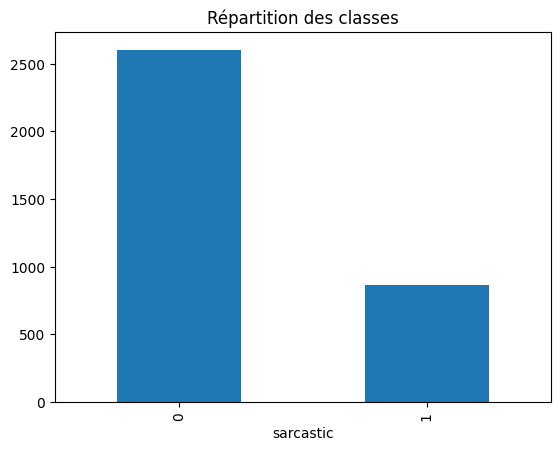

In [46]:

df['sarcastic'].value_counts().plot(kind='bar', title='Répartition des classes')

In [47]:

df['n_chars'] = df['tweet'].astype(str).apply(len)
df['n_words'] = df['tweet'].astype(str).apply(lambda x: len(x.split()))
print(df['n_chars'].head())
print(df['n_words'].head())
df[['n_chars','n_words']].describe()



0     57
1    133
2    236
3     80
4    193
Name: n_chars, dtype: int64
0    11
1    26
2    36
3    17
4    29
Name: n_words, dtype: int64


,n_chars,n_words
count,3468.000000,3468.000000
mean,104.259804,18.828143
std,63.499196,11.279310
min,2.000000,1.000000
25%,57.000000,10.000000
50%,91.000000,16.500000
75%,136.000000,25.000000
max,397.000000,61.000000


<Axes: xlabel='n_words', ylabel='Count'>

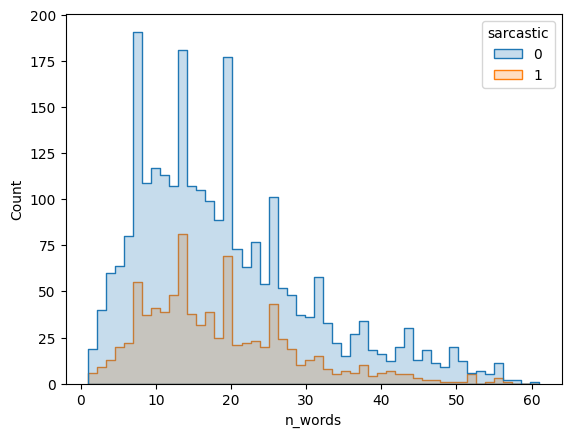

In [48]:
import seaborn as sns
sns.histplot(data=df, x='n_words', hue='sarcastic', bins=50, element='step')

*** WordCloud → une classe du module wordcloud qui crée un nuage de mots à partir d’un texte (les mots apparaissent plus grands s’ils sont plus fréquents).



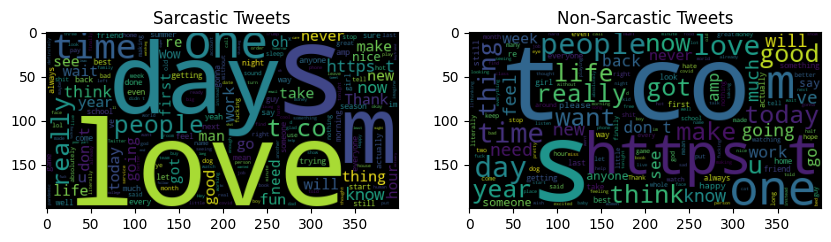

In [49]:
from wordcloud import WordCloud     
import matplotlib.pyplot as plt

df['tweet'] = df['tweet'].astype(str)
text_sarcastic = " ".join(df[df['sarcastic']==1]['tweet'])
text_non_sarcastic = " ".join(df[df['sarcastic']==0]['tweet'])

plt.figure(figsize=(10,5))    #Crée une figure (fenêtre graphique) de 10 pouces de large et 5 pouces de haut.
plt.subplot(1,2,1)            #crée le 1er graphique dans une grille de 1 ligne et 2 colonnes.(→ position 1 = à gauche)
plt.imshow(WordCloud().generate(text_sarcastic))
plt.title("Sarcastic Tweets")

plt.subplot(1,2,2)
plt.imshow(WordCloud().generate(text_non_sarcastic))
plt.title("Non-Sarcastic Tweets")
plt.show()


##  2. Prétraitement du texte



note: 
re.sub(pattern, replacement, text)
pattern → motif à chercher
replacement → ce par quoi on remplace le motif
text → texte dans lequel on cherche/remplace

In [78]:
import re
import nltk
import emoji
from textblob import TextBlob
import contractions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import pandas as pd
#stop_words contient la liste des mots à ignorer.
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def nltk_pos_to_wordnet(tag):
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('N'): return wordnet.NOUN
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def cleanText(text):
    #gerer les valeurs manquantes
    if pd.isna(text) or text == '':
        return ""
    #Convertir l'emoji en texte 😂 =>  face_with_tears_of_joy
    text = emoji.demojize(text, delimiters=(" ", " "))
    # Corrige les fautes d'orthographe "gr8" => "great" | "2day" => "today"
    #text=str(TextBlob(text).correct())
    #gerer les contraction "don't" => "do not"
    text = contractions.fix(text)
    #supprimer les caracteres repetes "loooove" => "love"
    text=re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    pos_tags = nltk.pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(token, nltk_pos_to_wordnet(pos)) for token, pos in pos_tags]
    return " ".join(lemmas)

df['text_clean'] = df['tweet'].apply(cleanText)
print(df[['tweet','sarcastic','text_clean']].head())



                                               tweet  sarcastic  \
0  The only thing I got from college is a caffein...          1   
1  I love it when professors draw a big question ...          1   
2  Remember the hundred emails from companies whe...          1   
3  Today my pop-pop told me I was not “forced” to...          1   
4  @VolphanCarol @littlewhitty @mysticalmanatee I...          1   

                                          text_clean  
0               thing get college caffeine addiction  
1  love professor draw big question mark next ans...  
2  remember hundred email company covid start get...  
3  today pop pop told force go college upside fac...  
4  volphancarol littlewhitty mysticalmanatee also...  


# **Machine Learning**

## 3. Vectorisation (transformation en nombres)

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

 # Séparer le texte et les labels
X_text = df['text_clean']
y = df['sarcastic']

#Division en train / validation 
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y,
    test_size=0.2,         # 20 % pour la validation
    random_state=42,       # pour reproductibilité
    stratify=y             # garde le même équilibre de classes
)

print(f"Train size : {len(X_train_text)} tweets")
print(f"Validation size : {len(X_val_text)} tweets")

#Création et apprentissage du TF-IDF ---
tfidf = TfidfVectorizer(
    max_features=12000,       
    ngram_range=(1, 2),       # unigrams + bigrams
    min_df=3,                 # supprime mots rares
    max_df=0.95,              # supprime mots trop fréquents
    sublinear_tf=True,        # améliore LR/svm(1 + log(TF) avec TF=nombre de fois où le mot apparaît dans le document)
    smooth_idf=True,          # naive bayes
    stop_words='english'      # enlève mots inutiles
)


# Apprentissage sur le jeu d'entraînement UNIQUEMENT
X_train = tfidf.fit_transform(X_train_text)

# Afficher les premiers mots appris par le TF-IDF
print(tfidf.get_feature_names_out()[:30])

# Transformation du jeu de validation (sans fit)
X_val = tfidf.transform(X_val_text)


print(f"Matrice train : {X_train.shape}")
print(f"Matrice val   : {X_val.shape}")

# Sauvegarde du vectorizer pour le test final 
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')




Train size : 2774 tweets
Validation size : 694 tweets
['able' 'absolute' 'absolutely' 'absolutely love' 'academic' 'accept'
 'access' 'accidentally' 'accord' 'account' 'achievement' 'acknowledge'
 'act' 'action' 'actual' 'actually' 'ad' 'add' 'admit' 'adult' 'aewallout'
 'afford' 'afraid' 'africa' 'afternoon' 'age' 'ago' 'agree' 'ah' 'ah yes']
Matrice train : (2774, 1971)
Matrice val   : (694, 1971)


['tfidf_vectorizer.pkl']

X_train = tfidf.fit_transform(X_train_text)

fit() → le vectorizer apprend le vocabulaire à partir des textes d’entraînement :

quels mots existent ?

combien de fois chaque mot apparaît ?

combien de documents contiennent chaque mot ?

transform() → il convertit ensuite ces textes en une matrice TF-IDF (une représentation numérique).

📌 Donc, fit_transform() = apprendre + transformer (en une seule étape).

X_val = tfidf.transform(X_val_text)

Elle n’apprend rien de nouveau.

Elle utilise le même vocabulaire et les mêmes poids TF-IDF déjà appris sur le train.

Elle transforme les textes du jeu de validation en utilisant les mêmes repères.

🎯 Utilité :

Cela permet d’avoir :

une cohérence entre les deux matrices (train et validation),

et surtout d’éviter la fuite de données (le TF-IDF ne voit pas les mots du test à l’avance).

## 4. Application d'algorithmes de Machine Learning

### Modèle 1 : Régression Logistique 

#### 1 / a - Régression Logistique (avec équilibrage => balanced)

Performance - Logistic Regression : 
Accuracy  : 0.6066
Precision : 0.2917
Recall    : 0.4046
F1-score  : 0.3390

 Classification report :
                 precision    recall  f1-score   support

Non sarcastique       0.77      0.67      0.72       521
    Sarcastique       0.29      0.40      0.34       173

       accuracy                           0.61       694
      macro avg       0.53      0.54      0.53       694
   weighted avg       0.65      0.61      0.63       694



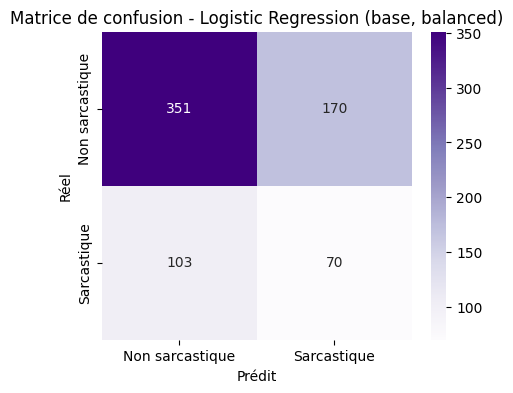


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 351 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 170 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 103 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 70 (Prédit 'Sarcastique' et c'était correct)


In [52]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Création du modèle
#    class_weight='balanced' : on équilibre les classes AU NIVEAU DU MODÈLE
log_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced',  # ÉQUILIBRAGE appliqué
    solver='lbfgs'
)

# Entraînement sur X_train, y_train 
log_model.fit(X_train, y_train)

# Prédiction sur la validation
y_pred = log_model.predict(X_val)

# Évaluation du modèle : calculer les métriques 
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("Performance - Logistic Regression : ")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}\n")
print(" Classification report :")
print(classification_report(y_val, y_pred, target_names=["Non sarcastique", "Sarcastique"]))

# Matrice de confusion 
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Non sarcastique", "Sarcastique"],
            yticklabels=["Non sarcastique", "Sarcastique"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Logistic Regression (base, balanced)")
plt.show()


print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm[1][1]} (Prédit 'Sarcastique' et c'était correct)")






#### 1 / b- Régression Logistique + Optimisation avec GridSearchCV

L’hyperparamètre :

C (La Force de la Punition)

solver (Le "Moteur" du Score)

penalty (Le Type de Punition):"'l1'","l2"


In [53]:

# Définition du modèle  (balanced)
log_model_base = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

# Grille d'hyperparamètres à tester
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 5, 10, 50, 100], # régularisation (inverse)
    'solver': ['lbfgs', 'liblinear']      # solveurs (saga utile pour l1 ou datasets grands)
}

# Création de GridSearchCV
grid_search = GridSearchCV(
    estimator=log_model_base,
    param_grid=param_grid,
    scoring='f1',   # important pour classe minoritaire
    cv=5,           # validation croisée 5 folds
    n_jobs=-1,      # utilise tous les cœurs CPU disponibles
    verbose=2
)

# Lancement de la recherche 
grid_search.fit(X_train, y_train)

# Résultats & meilleur estimateur
print("\n Meilleurs hyperparamètres trouvés par GridSearchCV : ")
print(grid_search.best_params_)
print(f"Meilleur score F1 (moyenne CV) : {grid_search.best_score_:.4f}")

best_log_model = grid_search.best_estimator_

# Prédiction sur la validation
y_pred_best = best_log_model.predict(X_val)

# Calcul des métriques 
acc_b = accuracy_score(y_val, y_pred_best)
prec_b = precision_score(y_val, y_pred_best)
rec_b = recall_score(y_val, y_pred_best)
f1_b = f1_score(y_val, y_pred_best)

print("\n Performance du meilleur modèle (GridSearch) : ")
print(f"Accuracy  : {acc_b:.4f}")
print(f"Precision : {prec_b:.4f}")
print(f"Recall    : {rec_b:.4f}")

print(f"F1-score  : {f1_b:.4f}\n")
print(" Classification report (meilleur) ")
print(classification_report(y_val, y_pred_best, target_names=["Non sarcastique", "Sarcastique"]))




Fitting 5 folds for each of 16 candidates, totalling 80 fits

 Meilleurs hyperparamètres trouvés par GridSearchCV : 
{'C': 0.001, 'solver': 'liblinear'}
Meilleur score F1 (moyenne CV) : 0.4029

 Performance du meilleur modèle (GridSearch) : 
Accuracy  : 0.5706
Precision : 0.2924
Recall    : 0.5087
F1-score  : 0.3713

 Classification report (meilleur) 
                 precision    recall  f1-score   support

Non sarcastique       0.78      0.59      0.67       521
    Sarcastique       0.29      0.51      0.37       173

       accuracy                           0.57       694
      macro avg       0.54      0.55      0.52       694
   weighted avg       0.66      0.57      0.60       694



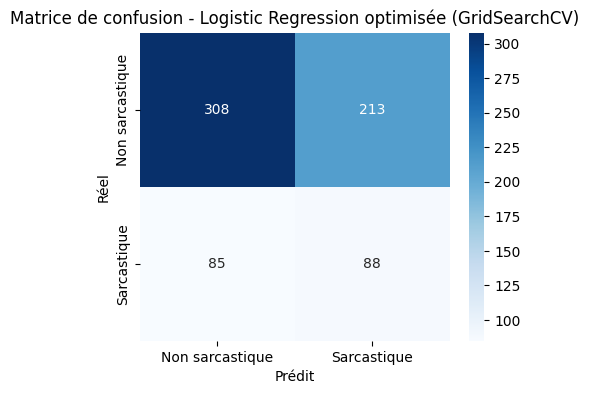


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 308 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 213 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 85 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 88 (Prédit 'Sarcastique' et c'était correct)

 Meilleur modèle optimisé sauvegardé sous 'best_model_logistic.pkl'


In [54]:
# Matrice de confusion pour le meilleur modèle
cm_b = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non sarcastique", "Sarcastique"],
            yticklabels=["Non sarcastique", "Sarcastique"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Logistic Regression optimisée (GridSearchCV)")
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm_b[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm_b[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm_b[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm_b[1][1]} (Prédit 'Sarcastique' et c'était correct)")



# Sauvegarde du modèle
joblib.dump(best_log_model, 'best_model_logistic.pkl')
print("\n Meilleur modèle optimisé sauvegardé sous 'best_model_logistic.pkl'")

### Modèle 2 : SVM

✔ Meilleur choix = SVM linéaire (LinearSVC)

Plus rapide, plus stable, excellent pour textes.

✔ SVM RBF = possible mais plus lent et souvent moins performant sur texte.

les hyperparametres de SVM linéaire :

✔ C est un paramètre de régularisation qui  contrôle le compromis entre :

.Bien classer les points d’entraînement (réduire les erreurs)

.Avoir un modèle plus simple et généralisable (éviter le sur-apprentissage)

✔ loss : fonction de perte (comment le modèle mesure ses erreurs)

.hinge:
    Les erreurs sont pénalisées proportionnellement à leur distance par rapport à la marge.
    Avantage : standard SVM, robuste.

.squared_hinge
    C’est une version “carrée” de la hinge loss.
    Les erreurs grosses sont pénalisées plus fortement (car on élève au carré).
    Peut donner une séparation plus stricte, mais sensible aux outliers.    


   

#### 2 / a - SVM (avec équilibrage => balanced)


 Performance du modèle SVM (Base) : 
Accuracy  : 0.5879
Précision : 0.2713
Rappel    : 0.3873
F1-score  : 0.3190

Rapport complet :

                     precision    recall  f1-score   support

Non-Sarcastique (0)       0.76      0.65      0.70       521
    Sarcastique (1)       0.27      0.39      0.32       173

           accuracy                           0.59       694
          macro avg       0.52      0.52      0.51       694
       weighted avg       0.64      0.59      0.61       694



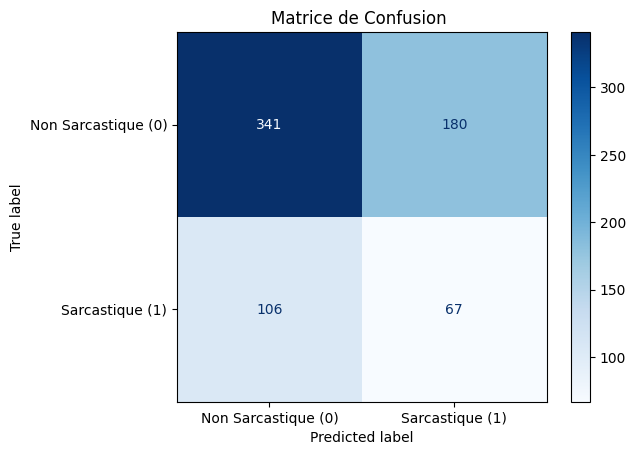


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 341 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 180 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 106 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 67 (Prédit 'Sarcastique' et c'était correct)


In [55]:
"""
 Par defaut le SVM linéaire travaille avec  ::
   C=1.0,
   loss='squared_hinge',
   penalty='l2'

"""

from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score,confusion_matrix, ConfusionMatrixDisplay

# Création du modèle LinearSVC avec class_weight='balanced'
linear_svm_balanced = LinearSVC(class_weight='balanced', random_state=42)

# Entraînement
linear_svm_balanced.fit(X_train, y_train)

# Prédiction
y_pred_linear = linear_svm_balanced.predict(X_val)


# Évaluation complète
acc_SV = accuracy_score(y_val, y_pred_linear)
prec_SV = precision_score(y_val, y_pred_linear)
rec_SV = recall_score(y_val, y_pred_linear)
f1_SV = f1_score(y_val, y_pred_linear)

print("\n Performance du modèle SVM (Base) : ")
print(f"Accuracy  : {acc_SV:.4f}")
print(f"Précision : {prec_SV:.4f}")
print(f"Rappel    : {rec_SV:.4f}")
print(f"F1-score  : {f1_SV:.4f}")

print("\nRapport complet :\n")

print(classification_report(y_val, y_pred_linear,target_names=['Non-Sarcastique (0)', 'Sarcastique (1)']))



#  Matrice de Confusion 

cm3 = confusion_matrix(y_val, y_pred_linear) # Utilise best_model ici

disp3 = ConfusionMatrixDisplay(
    confusion_matrix=cm3,
    display_labels=['Non Sarcastique (0)', 'Sarcastique (1)']
)

# Configuration de l'affichage
disp3.plot(cmap=plt.cm.Blues, values_format='g')
plt.title("Matrice de Confusion " ) # Titre dynamique
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm3[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm3[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm3[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm3[1][1]} (Prédit 'Sarcastique' et c'était correct)")


#### 2 / b - SVM + GridSearch

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleurs paramètres : {'C': 1, 'loss': 'hinge'}

Performance du SVM optimisé (GridSearch) :
Accuracy  : 0.5994
Précision : 0.3034
Rappel    : 0.4682
F1-score  : 0.3682

 Classification report (après optimisation) 
                     precision    recall  f1-score   support

Non-Sarcastique (0)       0.78      0.64      0.71       521
    Sarcastique (1)       0.30      0.47      0.37       173

           accuracy                           0.60       694
          macro avg       0.54      0.56      0.54       694
       weighted avg       0.66      0.60      0.62       694



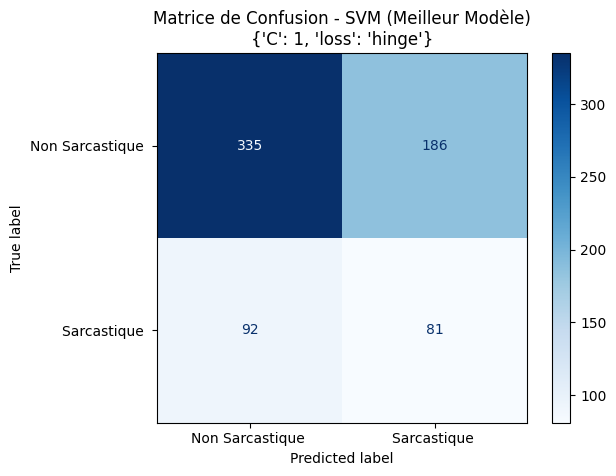


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 335 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 186 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 92 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 81 (Prédit 'Sarcastique' et c'était correct)


In [56]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score , confusion_matrix,ConfusionMatrixDisplay

# Modèle SVM linéaire
svm = LinearSVC(class_weight='balanced', random_state=42)

# Grille optimisée


param_grid = {
    'C': [0.1, 1, 5, 10],
    'loss': [ 'hinge','squared_hinge']
}

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1',     # F1 classe sarcastique
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Entraînement
grid_svm.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_

# Prédiction
y_pred_sv = best_svm.predict(X_val)

acc_Sg = accuracy_score(y_val, y_pred_sv)
prec_Sg = precision_score(y_val, y_pred_sv)
rec_Sg = recall_score(y_val, y_pred_sv)
f1_Sg = f1_score(y_val, y_pred_sv)

print("\nPerformance du SVM optimisé (GridSearch) :")
print(f"Accuracy  : {acc_Sg:.4f}")
print(f"Précision : {prec_Sg:.4f}")
print(f"Rappel    : {rec_Sg:.4f}")
print(f"F1-score  : {f1_Sg:.4f}")
print("\n Classification report (après optimisation) ")
print(classification_report(y_val, y_pred_sv,target_names=['Non-Sarcastique (0)', 'Sarcastique (1)']))



#  Matrice de Confusion 




cm2 = confusion_matrix(y_val, y_pred_sv, labels=best_svm.classes_) # Utilise best_model ici

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=['Non Sarcastique ', 'Sarcastique ']
)




# Configuration de l'affichage
disp2.plot(cmap=plt.cm.Blues, values_format='g')
plt.title(f"Matrice de Confusion - SVM (Meilleur Modèle)\n{grid_svm.best_params_}") # Titre dynamique
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm2[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm2[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm2[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm2[1][1]} (Prédit 'Sarcastique' et c'était correct)")


### Modele 3: Random Forest


les hyperparametres de Random Forest :
    
'n_estimators': nombre d’arbres

'max_depth': profondeur maximale d’un arbre
    
'min_samples_split':nombre minimum d’échantillons pour diviser un nœud

'min_samples_leaf': nombre minimum d’échantillons dans une feuille

'max_features': nombre de features utilisées pour chaque split

#### 3 / a - Random Forest (avec équilibrage => balanced)


 Performance du modèle Random forest (Base) : 
Accuracy  : 0.7147
Précision : 0.3596
Rappel    : 0.1850
F1-score  : 0.2443

Rapport complet :

                     precision    recall  f1-score   support

Non-Sarcastique (0)       0.77      0.89      0.82       521
    Sarcastique (1)       0.36      0.18      0.24       173

           accuracy                           0.71       694
          macro avg       0.56      0.54      0.53       694
       weighted avg       0.67      0.71      0.68       694



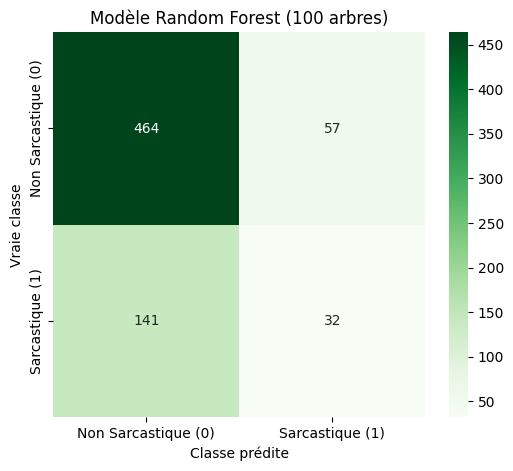


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 464 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 57 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 141 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 32 (Prédit 'Sarcastique' et c'était correct)


In [57]:
"""par defaut RandomForestClassifier  travaille avec  :

    'n_estimators': 100,
    'max_depth':none,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': sqrt 
"""

import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import time
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report




rf_balanced = RandomForestClassifier(n_estimators=100, 
                                     class_weight='balanced',  # L'option clé
                                     random_state=42, 
                                     n_jobs=-1)
rf_balanced.fit(X_train, y_train)

# Prédictions
y_pred_balanced = rf_balanced.predict(X_val)


# Évaluation complète
acc = accuracy_score(y_val, y_pred_balanced)
prec = precision_score(y_val, y_pred_balanced)
rec = recall_score(y_val, y_pred_balanced)
f1 = f1_score(y_val, y_pred_balanced)

print("\n Performance du modèle Random forest (Base) : ")
print(f"Accuracy  : {acc:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nRapport complet :\n")

print(classification_report(y_val, y_pred_balanced,target_names=['Non-Sarcastique (0)', 'Sarcastique (1)']))


cm_balanced = confusion_matrix(y_val, y_pred_balanced)
plt.figure(figsize=(6,5))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non Sarcastique (0)', 'Sarcastique (1)'], 
            yticklabels=['Non Sarcastique (0)', 'Sarcastique (1)'])
plt.title("Modèle Random Forest (100 arbres)")
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')

# Afficher les graphiques
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm_balanced[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm_balanced[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm_balanced[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm_balanced[1][1]} (Prédit 'Sarcastique' et c'était correct)")


 #### 3 / b - Random Forest + GridSearch 

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Meilleurs paramètres : {'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 700}

 Performance du modèle Random Forest(gridSearch) : 
Accuracy  : 0.6744
Précision : 0.3197
Rappel    : 0.2717
F1-score  : 0.2938

Rapport complet :

                     precision    recall  f1-score   support

Non-Sarcastique (0)       0.77      0.81      0.79       521
    Sarcastique (1)       0.32      0.27      0.29       173

           accuracy                           0.67       694
          macro avg       0.54      0.54      0.54       694
       weighted avg       0.66      0.67      0.67       694



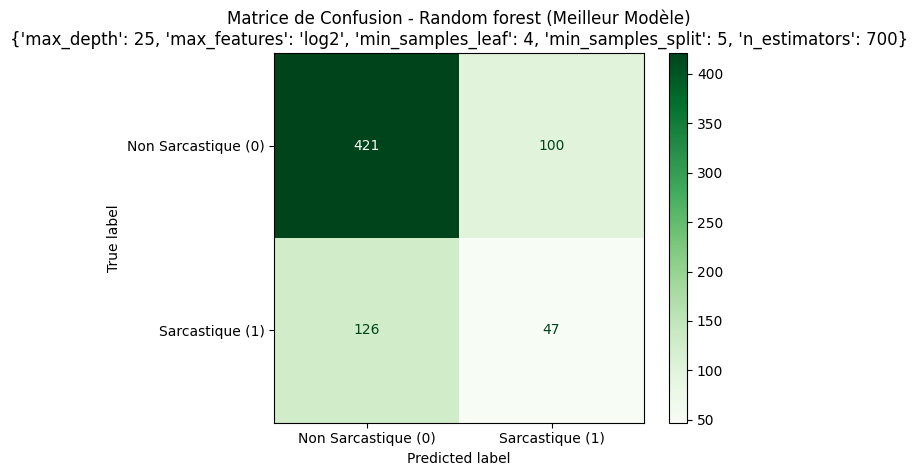


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 421 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 100 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 126 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 47 (Prédit 'Sarcastique' et c'était correct)


In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Définition du modèle

#augmente le poids des erreurs faites sur la classe 1 donc le modèle devient plus sensible à la classe minoritaire
rf = RandomForestClassifier(class_weight='balanced', random_state=42)



# Grille optimisée
""" 
max_depth, min_samples_split, min_samples_leaf => Simplifie l’arbre
max_features => Diversifie le modèle
n_estimators↑ => Stabilise

""" 

param_grid = {
    'n_estimators': [300,400, 500, 700], #nombre d’arbres
    'max_depth': [15, 20, 25], #profondeur maximale d’un arbre
    'min_samples_split': [5, 10], #nombre minimum d’échantillons pour diviser un nœud
    'min_samples_leaf': [2, 4],#nombre minimum d’échantillons dans une feuille
    'max_features': ['sqrt', 'log2'] # nombre de features utilisées pour chaque split

}

# GridSearch optimisé
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',            # F1-moyen OU 'f1_macro', mais ici tu veux la classe 1 → F1 pondéré
    cv=5,                    # 3 folds → assez pour texte + rapide
    n_jobs=-1,               # utilise tous les cœurs
    verbose=2
)

# Entraînement
grid.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres :", grid.best_params_)

# Performance sur validation
best_model = grid.best_estimator_
y_pred = best_model.predict(X_val)


# Évaluation complète
accR2 = accuracy_score(y_val, y_pred)
precR2 = precision_score(y_val, y_pred)
recR2 = recall_score(y_val, y_pred)
f1R2 = f1_score(y_val, y_pred)

print("\n Performance du modèle Random Forest(gridSearch) : ")
print(f"Accuracy  : {accR2:.4f}")
print(f"Précision : {precR2:.4f}")
print(f"Rappel    : {recR2:.4f}")
print(f"F1-score  : {f1R2:.4f}")

print("\nRapport complet :\n")
print(classification_report(y_val, y_pred,target_names=['Non-Sarcastique (0)', 'Sarcastique (1)']))

#print("F1 classe sarcastique (1) :", f1_score(y_val, y_pred, pos_label=1))



#  Matrice de Confusion 



# Calcul de la matrice
cm1 = confusion_matrix(y_val, y_pred, labels=best_model.classes_) # Utilise best_model ici

# Affichage de la matrice
# 'display_labels' utilise les noms que vous avez définis
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm1,
    display_labels=['Non Sarcastique (0)', 'Sarcastique (1)']
)

# Configuration de l'affichage
disp1.plot(cmap=plt.cm.Greens, values_format='g')
plt.title(f"Matrice de Confusion - Random forest (Meilleur Modèle)\n{grid.best_params_}") # Titre dynamique
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm1[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm1[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm1[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm1[1][1]} (Prédit 'Sarcastique' et c'était correct)")







### Modèle 4 : Naive Bayes 

Pour classer un texte comme sarcastique ou non, le type de Naive Bayes le plus courant et le plus recommandé est Multinomial Naive Bayes (MultinomialNB).

Pourquoi MultinomialNB ?
Le MultinomialNB est spécifiquement conçu pour les données de comptage (features discrètes).

Quand vous analysez du texte, la méthode la plus populaire est de transformer le texte en vecteurs de fréquence de mots (par exemple, en utilisant CountVectorizer ou TfidfVectorizer de scikit-learn).

Exemple : "Oh, super, encore une réunion."

Transformation : {oh: 1, super: 1, encore: 1, réunion: 1}

Le MultinomialNB est excellent pour gérer ce type de données. Il va apprendre la probabilité qu'un mot (comme "super" ou "encore") apparaisse dans un texte sarcastique par rapport à un texte non sarcastique.

 #### 4 / a - Naive Bayes (sans SMOTE)

Performance du modèle Naive Bayes : 
Accuracy  : 0.7450
Précision : 0.3000
Rappel    : 0.0173
F1-score  : 0.0328

Rapport de classification complet :

                 precision    recall  f1-score   support

Non sarcastique       0.75      0.99      0.85       521
    Sarcastique       0.30      0.02      0.03       173

       accuracy                           0.74       694
      macro avg       0.53      0.50      0.44       694
   weighted avg       0.64      0.74      0.65       694



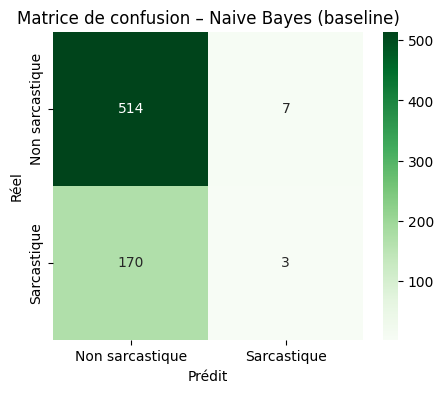


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 514 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 7 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 170 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 3 (Prédit 'Sarcastique' et c'était correct)


In [59]:
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Création du modèle de base
nb_model = MultinomialNB(alpha=1.0)

# Entraînement du modèle
nb_model.fit(X_train, y_train)

# Prédiction sur le jeu de validation
y_pred_nb = nb_model.predict(X_val)

# Évaluation des performances
acc = accuracy_score(y_val, y_pred_nb)
prec = precision_score(y_val, y_pred_nb)
rec = recall_score(y_val, y_pred_nb)
f1 = f1_score(y_val, y_pred_nb)

print("Performance du modèle Naive Bayes : ")
print(f"Accuracy  : {acc:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nRapport de classification complet :\n")
print(classification_report(y_val, y_pred_nb, target_names=["Non sarcastique", "Sarcastique"]))

# Matrice de confusion
cm = confusion_matrix(y_val, y_pred_nb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Non sarcastique", "Sarcastique"],
            yticklabels=["Non sarcastique", "Sarcastique"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion – Naive Bayes (baseline)")
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm[1][1]} (Prédit 'Sarcastique' et c'était correct)")





 #### 4 / b - Naive Bayes (sans SMOTE) + Optimisation avec GridSearchCV

L’hyperparamètre principal de MultinomialNB est alpha,
le coefficient de lissage de Laplace :

Trop grand → réduit l’impact des mots rares (sous-apprentissage)

Trop petit → le modèle peut sur-s’ajuster.

In [60]:
from sklearn.model_selection import GridSearchCV

# Modèle de base
nb = MultinomialNB()

# Grille des hyperparamètres
param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

# Configuration du GridSearch
grid_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid_nb,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Lancement de la recherche
grid_nb.fit(X_train, y_train)

# Meilleurs paramètres
print("\nMeilleur alpha trouvé : ")
print(grid_nb.best_params_)
print(f"Meilleur F1 (moyenne CV) : {grid_nb.best_score_:.4f}")

best_nb_model = grid_nb.best_estimator_

# Évaluation du modèle optimisé
y_pred_best_nb = best_nb_model.predict(X_val)

acc_b = accuracy_score(y_val, y_pred_best_nb)
prec_b = precision_score(y_val, y_pred_best_nb)
rec_b = recall_score(y_val, y_pred_best_nb)
f1_b = f1_score(y_val, y_pred_best_nb)

print("\nPerformance du Naive Bayes optimisé (GridSearch) :")
print(f"Accuracy  : {acc_b:.4f}")
print(f"Précision : {prec_b:.4f}")
print(f"Rappel    : {rec_b:.4f}")
print(f"F1-score  : {f1_b:.4f}")
print("\n Classification report (après optimisation) ")
print(classification_report(y_val, y_pred_best_nb, target_names=["Non sarcastique", "Sarcastique"]))




Fitting 5 folds for each of 6 candidates, totalling 30 fits

Meilleur alpha trouvé : 
{'alpha': 0.01}
Meilleur F1 (moyenne CV) : 0.2147

Performance du Naive Bayes optimisé (GridSearch) :
Accuracy  : 0.7305
Précision : 0.3704
Rappel    : 0.1156
F1-score  : 0.1762

 Classification report (après optimisation) 
                 precision    recall  f1-score   support

Non sarcastique       0.76      0.93      0.84       521
    Sarcastique       0.37      0.12      0.18       173

       accuracy                           0.73       694
      macro avg       0.57      0.53      0.51       694
   weighted avg       0.66      0.73      0.67       694



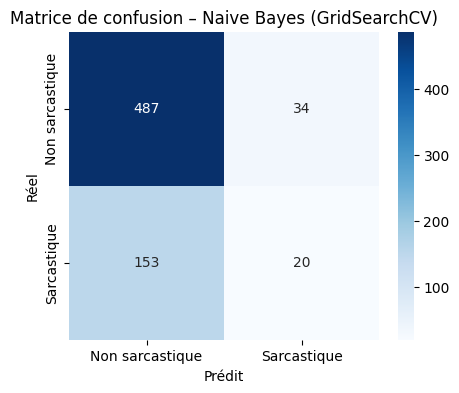


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 514 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 7 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 170 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 3 (Prédit 'Sarcastique' et c'était correct)


In [61]:
# Matrice de confusion
cm_best = confusion_matrix(y_val, y_pred_best_nb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non sarcastique", "Sarcastique"],
            yticklabels=["Non sarcastique", "Sarcastique"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion – Naive Bayes (GridSearchCV)")
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm[1][1]} (Prédit 'Sarcastique' et c'était correct)")



 #### 4 / c - Naive Bayes + GridSearchCV + SMOTE

On ne peut pas appliquer SMOTE sur X_train avant de lancer GridSearchCV. Pourquoi ? Car GridSearchCV fait une validation croisée (CV) à 5 "plis". Si on applique SMOTE avant, des informations du "pli 5" (qui sert de test) se retrouveraient dans les "plis 1-4" (qui servent d'entraînement) sous forme synthétique. C'est de la fuite de données (data leakage) et ça fausserait tes résultats.

Quand GridSearchCV va tester un "pli", le Pipeline va :

1/Appliquer SMOTE uniquement sur les données d'entraînement du pli.

2/Entraîner le modèle Naive Bayes sur ces données "smotées".

3/Évaluer le modèle sur le pli de validation (qui est resté déséquilibré et "propre").

In [62]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# gérer SMOTE + Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Créer le Pipeline ---
# On définit deux étapes :
# 1. 'smote' : Appliquer SMOTE pour équilibrer les données
# 2. 'nb'    : Appliquer le modèle Naive Bayes
pipeline_nb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('nb', MultinomialNB())
])

# Grille des hyperparamètres 
# IMPORTANT : on doit préfixer le paramètre 'alpha' par le nom de l'étape : 'nb__'
param_grid_nb_smote = {
    'nb__alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

# Configuration du GridSearch 
# On utilise le 'pipeline_nb' comme estimateur
grid_nb_smote = GridSearchCV(
    estimator=pipeline_nb,
    param_grid=param_grid_nb_smote,
    scoring='f1',  # On cherche toujours à optimiser le F1
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Lancement de la recherche 
# On entraîne le pipeline. SMOTE sera appliqué 5 fois (dans chaque fold de CV)
grid_nb_smote.fit(X_train, y_train)

# Résultats 
print("\nMeilleur alpha (avec SMOTE) : ")
print(grid_nb_smote.best_params_)
print(f"Meilleur F1 (moyenne CV) : {grid_nb_smote.best_score_:.4f}")

best_nb_smote_model = grid_nb_smote.best_estimator_

# Évaluation du modèle optimisé
y_pred_best_nb_smote = best_nb_smote_model.predict(X_val)

# Calcul des métriques
acc_s = accuracy_score(y_val, y_pred_best_nb_smote)
prec_s = precision_score(y_val, y_pred_best_nb_smote)
rec_s = recall_score(y_val, y_pred_best_nb_smote)
f1_s = f1_score(y_val, y_pred_best_nb_smote)

print("\nPerformance du Naive Bayes (GridSearch + SMOTE) :")
print(f"Accuracy  : {acc_s:.4f}")
print(f"Précision : {prec_s:.4f}")
print(f"Rappel    : {rec_s:.4f}")
print(f"F1-score  : {f1_s:.4f}")
print("\n Classification report (NB + SMOTE) ")
print(classification_report(y_val, y_pred_best_nb_smote, target_names=["Non sarcastique", "Sarcastique"]))

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Meilleur alpha (avec SMOTE) : 
{'nb__alpha': 1.0}
Meilleur F1 (moyenne CV) : 0.3951

Performance du Naive Bayes (GridSearch + SMOTE) :
Accuracy  : 0.6023
Précision : 0.3042
Rappel    : 0.4624
F1-score  : 0.3670

 Classification report (NB + SMOTE) 
                 precision    recall  f1-score   support

Non sarcastique       0.78      0.65      0.71       521
    Sarcastique       0.30      0.46      0.37       173

       accuracy                           0.60       694
      macro avg       0.54      0.56      0.54       694
   weighted avg       0.66      0.60      0.62       694



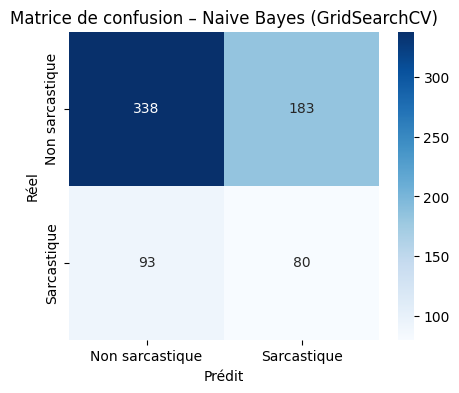


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 338 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 183 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 93 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 80 (Prédit 'Sarcastique' et c'était correct)

 Modèle Naive Bayes optimisé sauvegardé sous 'best_model_naivebayes.pkl'


In [63]:
# Matrice de confusion
cm_best = confusion_matrix(y_val, y_pred_best_nb_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non sarcastique", "Sarcastique"],
            yticklabels=["Non sarcastique", "Sarcastique"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion – Naive Bayes (GridSearchCV)")
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm_best[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm_best[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm_best[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm_best[1][1]} (Prédit 'Sarcastique' et c'était correct)")


# Sauvegarde du meilleur modèle
joblib.dump(best_nb_model, 'best_model_naivebayes.pkl')
print("\n Modèle Naive Bayes optimisé sauvegardé sous 'best_model_naivebayes.pkl'")

### Modèle 5 : K-Nearest Neighbors (KNN)

 #### 5 / a - KNN (sans SMOTE)


 Performance du modèle KNN (Base) : 
Accuracy  : 0.7046
Précision : 0.2949
Rappel    : 0.1329
F1-score  : 0.1833

Rapport complet :

                 precision    recall  f1-score   support

Non sarcastique       0.76      0.89      0.82       521
    Sarcastique       0.29      0.13      0.18       173

       accuracy                           0.70       694
      macro avg       0.53      0.51      0.50       694
   weighted avg       0.64      0.70      0.66       694



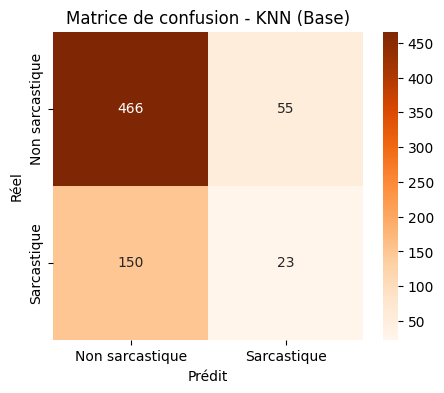


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 466 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 55 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 150 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 23 (Prédit 'Sarcastique' et c'était correct)


In [64]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Création du modèle KNN de base
knn_base = KNeighborsClassifier(n_neighbors=5, metric='cosine', weights='distance')

# Entraînement
knn_base.fit(X_train, y_train)

# Prédiction
y_pred_base = knn_base.predict(X_val)

# Évaluation complète
acc = accuracy_score(y_val, y_pred_base)
prec = precision_score(y_val, y_pred_base)
rec = recall_score(y_val, y_pred_base)
f1 = f1_score(y_val, y_pred_base)

print("\n Performance du modèle KNN (Base) : ")
print(f"Accuracy  : {acc:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nRapport complet :\n")
print(classification_report(y_val, y_pred_base, target_names=["Non sarcastique", "Sarcastique"]))

# Matrice de confusion
cm = confusion_matrix(y_val, y_pred_base)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Non sarcastique", "Sarcastique"],
            yticklabels=["Non sarcastique", "Sarcastique"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - KNN (Base)")
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm[1][1]} (Prédit 'Sarcastique' et c'était correct)")




 #### 5 / b - KNN (sans SMOTE) + Optimisation avec GridSearchCV

In [65]:
from sklearn.model_selection import GridSearchCV

# Modèle KNN pour GridSearch
knn = KNeighborsClassifier()

# Grille d'hyperparamètres
param_grid ={
    'n_neighbors': [5, 7, 11],          # Nombres de voisins à tester
    'metric': ['cosine', 'manhattan'],  # Métriques de distance
    'weights': ['uniform', 'distance']  # 'distance' (ton choix) ou 'uniform'
}

# GridSearchCV
grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_knn.fit(X_train, y_train)

# Meilleurs hyperparamètres
print("\nMeilleurs hyperparamètres trouvés pour KNN : ")
print(grid_search_knn.best_params_)
print(f"Meilleur F1-score (CV) : {grid_search_knn.best_score_:.4f}")

# Extraction du meilleur modèle
best_knn = grid_search_knn.best_estimator_

# Prédiction
y_pred_knn = best_knn.predict(X_val)

# Évaluation complète
acc = accuracy_score(y_val, y_pred_knn)
prec = precision_score(y_val, y_pred_knn)
rec = recall_score(y_val, y_pred_knn)
f1 = f1_score(y_val, y_pred_knn)

print("\n Performance du modèle KNN (GridSearch) : ")
print(f"Accuracy  : {acc:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nRapport complet :\n")
print(classification_report(y_val, y_pred_knn, target_names=["Non sarcastique", "Sarcastique"]))





Fitting 5 folds for each of 12 candidates, totalling 60 fits

Meilleurs hyperparamètres trouvés pour KNN : 
{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Meilleur F1-score (CV) : 0.3223

 Performance du modèle KNN (GridSearch) : 
Accuracy  : 0.2968
Précision : 0.2504
Rappel    : 0.9133
F1-score  : 0.3930

Rapport complet :

                 precision    recall  f1-score   support

Non sarcastique       0.76      0.09      0.16       521
    Sarcastique       0.25      0.91      0.39       173

       accuracy                           0.30       694
      macro avg       0.51      0.50      0.28       694
   weighted avg       0.63      0.30      0.22       694



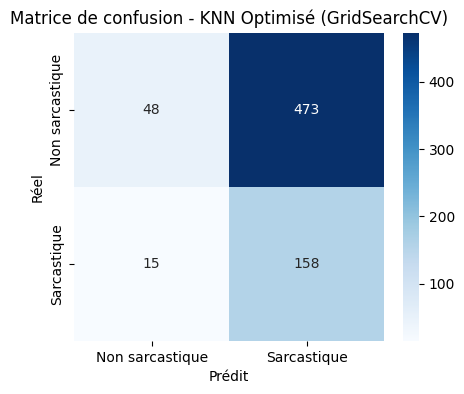


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 48 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 473 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 15 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 158 (Prédit 'Sarcastique' et c'était correct)


In [66]:
# Matrice de confusion
cm = confusion_matrix(y_val, y_pred_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non sarcastique", "Sarcastique"],
            yticklabels=["Non sarcastique", "Sarcastique"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - KNN Optimisé (GridSearchCV)")
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm[1][1]} (Prédit 'Sarcastique' et c'était correct)")



 #### 5 / c - KNN + GridSearchCV + SMOTE

In [67]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

from imblearn.pipeline import Pipeline as ImbPipeline  # Pipeline spécial
from imblearn.over_sampling import SMOTE

# Création du Pipeline 
# On dit à scikit-learn : "d'abord tu appliques SMOTE, ensuite tu appliques KNN"
pipeline_knn = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    # n_jobs=-1 pour accélérer l'entraînement
    ('knn', KNeighborsClassifier(n_jobs=-1)) 
])

# Grille des hyperparamètres 
# On teste différents nombres de voisins, métriques et poids
# Note : on préfixe par 'knn__' (nom de l'étape dans le pipeline)
param_grid_knn = {
    'knn__n_neighbors': [5, 7, 11],          # Nombres de voisins à tester
    'knn__metric': ['cosine', 'manhattan'],  # Métriques de distance
    'knn__weights': ['uniform', 'distance']  # 'distance' (ton choix) ou 'uniform'
}

# Configuration du GridSearch ---
# On passe le PIPELINE comme estimateur
grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    scoring='f1',  # On optimise le F1-score
    cv=5,
    n_jobs=-1,     # Utilise tous les cœurs pour le GridSearch
    verbose=2
)

# Lancement de la recherche 
grid_knn.fit(X_train, y_train)

# Résultats 
print("\nMeilleurs hyperparamètres trouvés pour KNN (avec SMOTE) : ")
print(grid_knn.best_params_)
print(f"Meilleur F1 (moyenne CV) : {grid_knn.best_score_:.4f}")

# 'best_estimator_' est le pipeline complet et optimisé
best_knn_model = grid_knn.best_estimator_

# Évaluation du modèle optimisé
y_pred_best_knn = best_knn_model.predict(X_val)

# Calcul des métriques
acc_b = accuracy_score(y_val, y_pred_best_knn)
prec_b = precision_score(y_val, y_pred_best_knn)
rec_b = recall_score(y_val, y_pred_best_knn)
f1_b = f1_score(y_val, y_pred_best_knn)

print("\nPerformance du KNN optimisé (GridSearch + SMOTE) :")
print(f"Accuracy  : {acc_b:.4f}")
print(f"Précision : {prec_b:.4f}")
print(f"Rappel    : {rec_b:.4f}")
print(f"F1-score  : {f1_b:.4f}")
print("\n Classification report (KNN optimisé + SMOTE) ")
print(classification_report(y_val, y_pred_best_knn, target_names=["Non sarcastique", "Sarcastique"]))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Meilleurs hyperparamètres trouvés pour KNN (avec SMOTE) : 
{'knn__metric': 'cosine', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Meilleur F1 (moyenne CV) : 0.3854

Performance du KNN optimisé (GridSearch + SMOTE) :
Accuracy  : 0.5447
Précision : 0.2813
Rappel    : 0.5318
F1-score  : 0.3680

 Classification report (KNN optimisé + SMOTE) 
                 precision    recall  f1-score   support

Non sarcastique       0.78      0.55      0.64       521
    Sarcastique       0.28      0.53      0.37       173

       accuracy                           0.54       694
      macro avg       0.53      0.54      0.51       694
   weighted avg       0.66      0.54      0.58       694



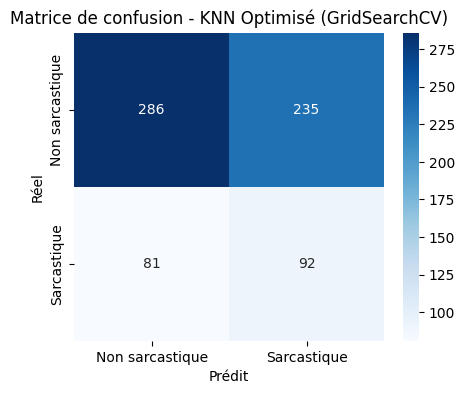


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 286 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 235 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 81 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 92 (Prédit 'Sarcastique' et c'était correct)


In [68]:
# Matrice de confusion
cm = confusion_matrix(y_val, y_pred_best_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non sarcastique", "Sarcastique"],
            yticklabels=["Non sarcastique", "Sarcastique"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - KNN Optimisé (GridSearchCV)")
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm[1][1]} (Prédit 'Sarcastique' et c'était correct)")




KNN fonctionne très mal avec des données comme TF-IDF.

* Le problème : Ton TF-IDF a 1971 dimensions (colonnes). KNN est un algorithme basé sur la "distance" entre les points.

* La "Malédiction de la Dimension" : Dans un espace à 1971 dimensions, tous les points sont très loin les uns des autres. La notion de "voisin proche" n'a plus beaucoup de sens.

## 5. Comparaison et sélection du meilleur modèle

### les AUC de tous tes modèles

 CALCUL DES AUC POUR TOUS LES MODÈLES 
AUC Régression Logistique : 0.5775
AUC Naive Bayes : 0.5724
AUC KNN : 0.5556
AUC Random Forest : 0.5848
AUC SVM : 0.5584


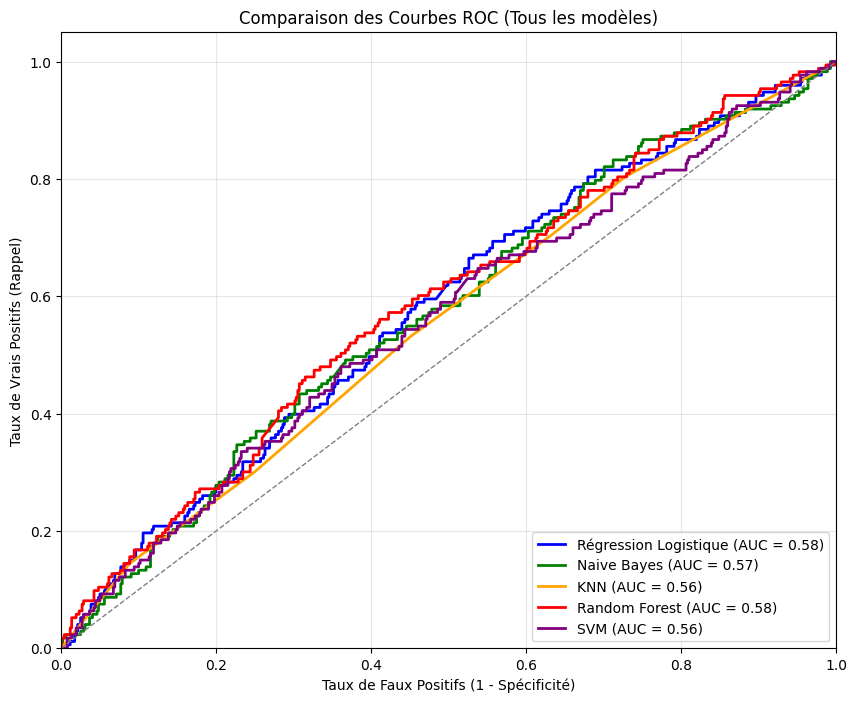

In [69]:
from sklearn.metrics import roc_auc_score
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print(" CALCUL DES AUC POUR TOUS LES MODÈLES ")

# 1. Régression Logistique
# (Vérifie que ta variable s'appelle bien 'best_log_model' ou 'log_model')
probs_log = best_log_model.predict_proba(X_val)[:, 1]
auc_log = roc_auc_score(y_val, probs_log)
print(f"AUC Régression Logistique : {auc_log:.4f}")

# 2. Naive Bayes
probs_nb = best_nb_smote_model.predict_proba(X_val)[:, 1]
auc_nb = roc_auc_score(y_val, probs_nb)
print(f"AUC Naive Bayes : {auc_nb:.4f}")

# 3. KNN
probs_knn = best_knn_model.predict_proba(X_val)[:, 1]
auc_knn = roc_auc_score(y_val, probs_knn)
print(f"AUC KNN : {auc_knn:.4f}")


# 4. Random Forest
probs_rf = best_model.predict_proba(X_val)[:, 1]
auc_rf = roc_auc_score(y_val, probs_rf)
print(f"AUC Random Forest : {auc_rf:.4f}")

# 5. SVM (LinearSVC n'a pas predict_proba, on utilise decision_function)
scores_svm = best_svm.decision_function(X_val)
auc_svm = roc_auc_score(y_val, scores_svm)
print(f"AUC SVM : {auc_svm:.4f}")


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# --- Fonction pour tracer une courbe ---
def plot_roc(y_true, y_probs, label, color):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

# --- 1. Tracer les modèles classiques ---
# (Vérifie que tu as bien ces variables calculées à l'étape d'avant)
plot_roc(y_val, probs_log, "Régression Logistique", "blue")
plot_roc(y_val, probs_nb,  "Naive Bayes", "green")
plot_roc(y_val, probs_knn, "KNN", "orange")
plot_roc(y_val, probs_rf,  "Random Forest", "red")
plot_roc(y_val, scores_svm, "SVM", "purple") # Attention: SVM utilise 'scores' pas 'probs

# --- 3. Mise en forme du graphique ---
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--') # Ligne du hasard
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Rappel)')
plt.title('Comparaison des Courbes ROC (Tous les modèles)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()



### TABLEAU COMPARATIF

In [70]:
import pandas as pd


resultats = [
    {
        "Modèle": "Régression Logistique",
        "Vectorisation": "TF-IDF",
        "Accuracy": 0.5706,      
        "Précision": 0.2924,     
        "Rappel": 0.5087,        
        "F1-Score": 0.3713,      
        "AUC": 0.5775            
    },
    {
        "Modèle": "Naive Bayes (SMOTE)",
        "Vectorisation": "TF-IDF",
        "Accuracy": 0.6023,
        "Précision": 0.3042,
        "Rappel": 0.4624,
        "F1-Score": 0.3670,
        "AUC": 0.5724           
    },
    {
        "Modèle": "KNN (SMOTE)",
        "Vectorisation": "TF-IDF",
        "Accuracy": 0.5447,
        "Précision": 0.2813,
        "Rappel": 0.5318,
        "F1-Score": 0.3680,
        "AUC": 0.5556
    },
    {
        "Modèle": "SVM (LinearSVC)",
        "Vectorisation": "TF-IDF",
        "Accuracy": 0.5994,        
        "Précision": 0.3034,       
        "Rappel": 0.4682,          
        "F1-Score": 0.3682,        
        "AUC": 0.56            
    },
    {
        "Modèle": "Random Forest",
        "Vectorisation": "TF-IDF",
        "Accuracy": 0.6744,        
        "Précision": 0.3197,       
        "Rappel": 0.2717,          
        "F1-Score":0.2938 ,        
        "AUC": 0.58            
    },
    
]

# Création du DataFrame
df_comparatif = pd.DataFrame(resultats)

# Mise en forme : on arrondit à 4 chiffres
df_comparatif = df_comparatif.round(4)

# Tri par F1-Score (ou AUC, selon ce que tu veux mettre en avant)
df_comparatif = df_comparatif.sort_values(by="F1-Score", ascending=False)

# Affichage
print(" TABLEAU COMPARATIF FINAL ")
display(df_comparatif)

 TABLEAU COMPARATIF FINAL 


,Modèle,Vectorisation,Accuracy,Précision,Rappel,F1-Score,AUC
0,Régression Logistique,TF-IDF,0.5706,0.2924,0.5087,0.3713,0.5775
3,SVM (LinearSVC),TF-IDF,0.5994,0.3034,0.4682,0.3682,0.5600
2,KNN (SMOTE),TF-IDF,0.5447,0.2813,0.5318,0.3680,0.5556
1,Naive Bayes (SMOTE),TF-IDF,0.6023,0.3042,0.4624,0.3670,0.5724
4,Random Forest,TF-IDF,0.6744,0.3197,0.2717,0.2938,0.5800


## 6. Test final et sauvegarde


=== Résultat final du Regression Logistic ===
Accuracy : 0.5807
Precision: 0.1854
Recall   : 0.5700
F1-score : 0.2798
AUC      : 0.6234

--- Rapport complet ---
                 precision    recall  f1-score   support

Non sarcastique       0.89      0.58      0.70      1200
    Sarcastique       0.19      0.57      0.28       200

       accuracy                           0.58      1400
      macro avg       0.54      0.58      0.49      1400
   weighted avg       0.79      0.58      0.64      1400



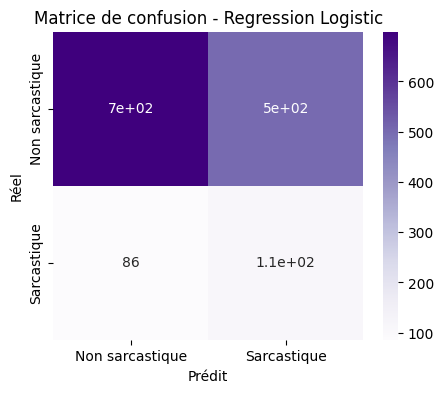

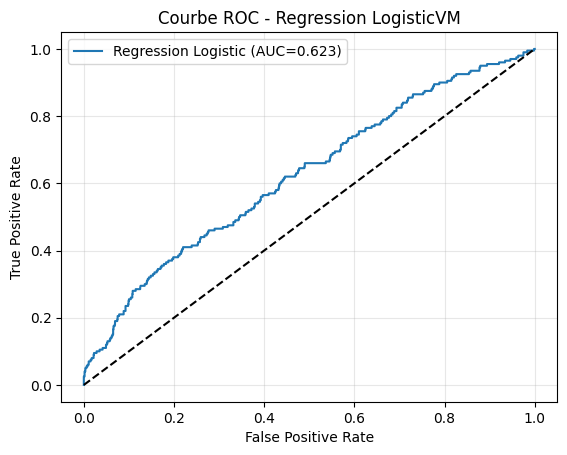


✔ Fichier 'final_Reg_predictions.csv' sauvegardé.


In [71]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

#  Recharger le modèle et le TF-IDF

Reg_model = joblib.load("best_model_logistic.pkl")
tfidf     = joblib.load("tfidf_vectorizer.pkl")

#  Charger le fichier test

test_df = pd.read_csv("task_A_En_test.csv")

# Vérification des colonnes
assert "text" in test_df.columns, "La colonne 'text' n'existe pas dans test_df"
assert "sarcastic" in test_df.columns, "La colonne 'sarcastic' n'existe pas dans test_df"

#  Nettoyer les tweets AVEC ta fonction cleanText

test_df["text_clean"] = test_df["text"].apply(cleanText)

#  Transformer avec TF-IDF

X_test = tfidf.transform(test_df["text_clean"])
y_test = test_df["sarcastic"].astype(int).values

# Prédictions

y_pred = Reg_model.predict(X_test)

# Pour la courbe ROC :
if hasattr(Reg_model, "predict_proba"):
    y_score = Reg_model.predict_proba(X_test)[:, 1]
else:
    y_score = Reg_model.decision_function(X_test)

# Métriques finales

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_score)

print("\n=== Résultat final du Regression Logistic ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\n--- Rapport complet ---")
print(classification_report(
    y_test, y_pred,
    target_names=["Non sarcastique", "Sarcastique"]
))

#  Matrice de confusion

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Purples",
            xticklabels=["Non sarcastique","Sarcastique"],
            yticklabels=["Non sarcastique","Sarcastique"])
plt.title("Matrice de confusion - Regression Logistic")
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.show()

# Courbe ROC

fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr, label=f"Regression Logistic (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Regression LogisticVM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Sauvegarde des prédictions

test_df["prediction"] = y_pred
test_df[["text","prediction"]].to_csv("final_Reg_predictions.csv", index=False)

print("\n✔ Fichier 'final_Reg_predictions.csv' sauvegardé.") 

# **Deep Learning** 

## 3. Application d'algorithmes de Deep Learning

### Modèle 1 : BERT

Pour BERT, il faut utiliser le texte normal, PAS clean_text.

Parce que BERT est un modèle pré-entraîné sur un énorme corpus de texte naturel (Wikipedia, livres, web…).
Donc il comprend mieux le langage naturel complet, avec :

majuscules/minuscules

ponctuation

contractions ("don’t")

emojis

hashtags

mentions

la structure réelle d’un tweet

Si tu lui donnes un texte trop nettoyé, tu détruis l’information linguistique qu'il utilise pour comprendre un texte.

#### **le "cerveau"**

#### ⚠️ ALERTE IMPORTANTE POUR L'ÉVALUATION (Gain de Temps) ⚠️

Cette cellule et les suivantes **rechargent** le modèle BERT entraîné (`bert_sarcasm_model`) et son tokenizer depuis le disque.

Il n'est **PAS** nécessaire de ré-exécuter la phase d'entraînement (`trainer.train()`) qui prend plusieurs heures. Les poids optimisés (« le cerveau » du modèle) ayant déjà été sauvegardés, nous passons **directement au chargement du modèle** dans la cellule suivante pour procéder à l'évaluation finale.

---

In [72]:
"""import random
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from torch.utils.data import Dataset
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
import transformers


# FIX SEED (reproducibility)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


#  DEVICE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)


#  RAW TEXT (IMPORTANT FOR BERT)

X_text = df["tweet"]  
y = df["sarcastic"]

#  4) SPLIT
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train size:", len(X_train_text))
print("Validation size:", len(X_val_text))

#  TOKENIZER
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

#  CLASS WEIGHTS
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("\nPoids des classes:", class_weights_tensor)

#  CUSTOM BERT WITH WEIGHTED LOSS

class WeightedBertForSequenceClassification(BertForSequenceClassification):
    def __init__(self, config, class_weights=None):
        super().__init__(config)
        self.class_weights = class_weights
        self.loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)

    def compute_loss(self, model_outputs, labels):
        logits = model_outputs.logits
        return self.loss_fct(logits, labels)

model = WeightedBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    class_weights=class_weights_tensor
)
model.to(device)
print("\nBERT loaded on:", device)

# DATASET CLASS
class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

train_dataset = SarcasmDataset(X_train_text, y_train, tokenizer)
val_dataset   = SarcasmDataset(X_val_text, y_val, tokenizer)

#  METRICS
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }

#  TRAINING ARGUMENTS (with AUTOMATIC FALLBACK)

print("\nTransformers version detected:", transformers.__version__)

try:
    # Try modern version
    training_args = TrainingArguments(
        output_dir="./results_bert",
        num_train_epochs=2,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=100,
        weight_decay=0.01,
        logging_dir="./logs",
    )
    print(" Modern TrainingArguments active (evaluation_strategy OK).")

except TypeError:
    # Fallback for old versions
    print(" Old Transformers version detected → fallback mode activated.")

    training_args = TrainingArguments(
        output_dir="./results_bert",
        num_train_epochs=2,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        do_train=True,
        do_eval=True,
        save_steps=1000,   # instead of save_strategy
        logging_steps=100,
        weight_decay=0.01,
        logging_dir="./logs",
    )
    print("✔ Fallback arguments loaded.")

#  TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# TRAINING
print("\n--- Fine-Tuning BERT (weighted loss) ---")
trainer.train()
"""

'import random\nimport torch\nimport numpy as np\nimport pandas as pd\n\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.utils.class_weight import compute_class_weight\nfrom sklearn.metrics import (\n    f1_score, accuracy_score, precision_score, recall_score,\n    classification_report, confusion_matrix\n)\n\nfrom transformers import (\n    BertTokenizerFast,\n    BertForSequenceClassification,\n    Trainer,\n    TrainingArguments\n)\n\nfrom torch.utils.data import Dataset\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nimport torch.nn as nn\nimport transformers\n\n\n# FIX SEED (reproducibility)\n\nSEED = 42\nrandom.seed(SEED)\nnp.random.seed(SEED)\ntorch.manual_seed(SEED)\nif torch.cuda.is_available():\n    torch.cuda.manual_seed_all(SEED)\n\n\n#  DEVICE\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nprint("Device utilisé :", device)\n\n\n#  RAW TEXT (IMPORTANT FOR BERT)\n\nX_text = df["tweet"]  \ny = df["sarcastic"]\n\n#  4) SPL

In [ ]:

"""import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from torch.utils.data import Dataset

#  SEED + DEVICE
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Device utilisé =", device)

#  CHARGER LES DONNÉES
df = pd.read_csv("train.En.csv")

X_text = df["tweet"]
y = df["sarcastic"]

# SPLIT TRAIN / VAL

X_train, X_val, y_train, y_val = train_test_split(
    X_text, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print(" Train:", len(X_train), " | Val:", len(X_val))

# TOKENIZER
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

#  DATASET

Code / Étape,Description
""""""class SarcasmDataset(Dataset):,Définit une classe qui hérite de Dataset de PyTorch.
__len__,Retourne le nombre total d'échantillons (tweets) dans le jeu de données.
"__getitem__(self, idx)","Cœur de l'opération. Cette fonction est appelée pour charger un seul échantillon par son index : elle prend le texte, le tokenize avec le tokenizer de BERT, assure un padding (remplissage) et une truncation (troncation) à max_len=128, et retourne un dictionnaire contenant :"
"input_ids, attention_mask",Les identifiants des tokens et le masque d'attention (qui indique à BERT quels tokens sont réels et lesquels sont du padding).
labels,L'étiquette (0 ou 1) convertie en tenseur PyTorch.
train_dataset = SarcasmDataset(...),Création des objets Dataset pour l'entraînement et la validation.""""""

class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels": torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

train_dataset = SarcasmDataset(X_train, y_train, tokenizer)
val_dataset   = SarcasmDataset(X_val, y_val, tokenizer)

#  CLASS WEIGHTS (déséquilibre)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(" Class Weights =", class_weights)

#  BERT + FOCAL LOSS
class BertWithFocalLoss(BertForSequenceClassification):
    def __init__(self, config, class_weights=None, gamma=2.0):
        super().__init__(config)
        self.gamma = gamma
        self.class_weights = class_weights

    def compute_loss(self, outputs, labels):
        logits = outputs.logits
        ce = F.cross_entropy(logits, labels, weight=self.class_weights, reduction="none")
        pt = torch.exp(-ce)
        focal = (1 - pt)**self.gamma * ce
        return focal.mean()

model = BertWithFocalLoss.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    class_weights=class_weights
).to(device)

print(" Modèle chargé (BERT + Focal Loss)")

# TRAINING ARGUMENTS (avec fallback)
try:
    training_args = TrainingArguments(
        output_dir="bert_sarcasm_optimized",
        num_train_epochs=4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_ratio=0.1,
        weight_decay=0.01,
        learning_rate=2e-5,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss"
    )
    print(" Modern TrainingArguments OK")
except TypeError:
    print(" Version Transformers ancienne → fallback activé")
    training_args = TrainingArguments(
        output_dir="bert_sarcasm_optimized",
        num_train_epochs=4,
        per_device_train_batch_size=16,
        logging_steps=50
    )

#  TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

#  TRAINING
print("\n Entraînement en cours…")
trainer.train()
print("\n Entraînement terminé !")

#  SAUVEGARDE
SAVE_DIR = "bert_sarcasm_optimized"
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("\n✔ Modèle sauvegardé dans:", SAVE_DIR)

#  ÉVALUATION (PREDICTION)
print("\n Final Evaluation")

pred_output = trainer.predict(val_dataset)
logits = pred_output.predictions
labels = pred_output.label_ids

probs = F.softmax(torch.tensor(logits), dim=-1).numpy()
probs_sarcastic = probs[:, 1]

"""

📌 Device utilisé = cpu
📌 Train: 2774  | Val: 694
📌 Class Weights = tensor([0.6668, 1.9986])


Some weights of BertWithFocalLoss were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


📌 Modèle chargé (BERT + Focal Loss)
⚠️ Version Transformers ancienne → fallback activé

🚀 Entraînement en cours…


c:\Python310-64bit\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
50,0.601200
100,0.570300
150,0.544500
200,0.532900
250,0.493100
300,0.460700
350,0.476300
400,0.237800
450,0.186600
500,0.192300


c:\Python310-64bit\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



🎉 Entraînement terminé !

✔ Modèle sauvegardé dans: bert_sarcasm_optimized

📌 Final Evaluation


c:\Python310-64bit\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



🎯 Meilleur seuil: 0.15000000000000002 | F1: 0.4294117647058823


Le problème de  modèle BERT actuel : Il est trop "timide".

Il a une Précision correcte (0.48) : quand il ose dire "C'est sarcastique", il ne se trompe pas trop.

Il a un Rappel horrible (0.16) : il n'ose presque jamais le dire. Il rate 84% des sarcasmes.

La solution ? Changer le Seuil de Décision (Threshold Moving).

 L'Astuce du Seuil (La solution magique)
Par défaut, le modèle dit "C'est sarcastique" si la probabilité est supérieure à 50% (0.50). Comme le modèle est timide, on va lui dire : "C'est bon, si tu es sûr à 25%, dis que c'est sarcastique !"

Cela va faire exploser le Rappel et donc améliorer F1-Score.

Par défaut, la classification utilise un seuil de décision de 0.5 (argmax). En raison du déséquilibre des classes, nous avons remplacé cette méthode par une optimisation du seuil (Threshold Tuning). Nous convertissons les sorties en probabilités via Softmax et sélectionnons le seuil qui maximise le F1-Score sur l'ensemble de validation.

##### **Modele Bert**

##### **Il n'est pas nécessaire de refaire tout le processus d'entraînement de BERT. C'est l'un des grands avantages d'avoir sauvegardé le modèle (le "cerveau")**

##### **on pourrait simplement recharger le modèle entraîné, ce qui ne prend que quelques secondes.**

In [101]:
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from transformers import BertTokenizerFast, BertForSequenceClassification

#  Load trained model + tokenizer
print(" Loading BERT model...")
model = BertForSequenceClassification.from_pretrained("bert_sarcasm_optimized")
tokenizer = BertTokenizerFast.from_pretrained("bert_sarcasm_optimized")
model.eval()

# Load validation data
df = pd.read_csv("train.En.csv")
X_text = df["tweet"]
y = df["sarcastic"]

X_train, X_val, y_train, y_val = train_test_split(
    X_text, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

#  Tokenization
pred_output = trainer.predict(val_dataset)
logits = pred_output.predictions
labels = pred_output.label_ids


#  Predictions
with torch.no_grad():
    logits = model(**enc).logits

probs = torch.softmax(logits, dim=1).numpy()
probs_sarcastic = probs[:, 1]

#  Threshold Optimization (OPTION PRO)
best_f1 = 0
best_threshold = 0.5

for t in np.arange(0.1, 0.6, 0.01):
    preds_tmp = (probs_sarcastic > t).astype(int)
    f1 = f1_score(y_val, preds_tmp)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\n Meilleur seuil: = {best_threshold:.2f} | F1 = {best_f1:.4f}")

# Final Predictions
final_preds = (probs_sarcastic > best_threshold).astype(int)



 Loading BERT model...


c:\Python310-64bit\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



 Meilleur seuil: = 0.17 | F1 = 0.4332



=== Résultat final BERT ===
Accuracy : 0.7248
Precision: 0.4451
Recall   : 0.4220
F1-score : 0.4332
AUC      : 0.6237

                 precision    recall  f1-score   support

Non sarcastique       0.81      0.83      0.82       521
    Sarcastique       0.45      0.42      0.43       173

       accuracy                           0.72       694
      macro avg       0.63      0.62      0.63       694
   weighted avg       0.72      0.72      0.72       694



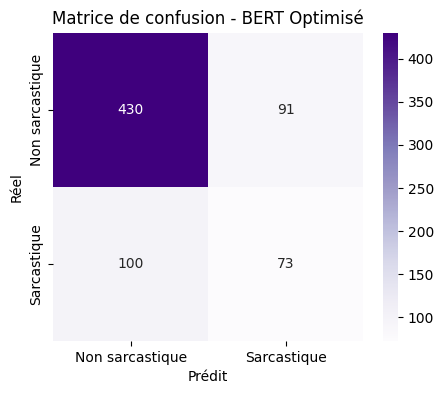


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 430 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 91 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 100 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 73 (Prédit 'Sarcastique' et c'était correct)


In [102]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
# METRIQUES FINALES

acc = accuracy_score(labels, final_preds)
prec = precision_score(labels, final_preds)
rec  = recall_score(labels, final_preds)
f1   = f1_score(labels, final_preds)
auc  = roc_auc_score(labels, final_preds)

print(f"""
=== Résultat final BERT ===
Accuracy : {acc:.4f}
Precision: {prec:.4f}
Recall   : {rec:.4f}
F1-score : {f1:.4f}
AUC      : {auc:.4f}
""")

print(classification_report(
    labels, final_preds,
    target_names=["Non sarcastique", "Sarcastique"]
))

# MATRICE DE CONFUSION
cm = confusion_matrix(labels, final_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Purples", fmt='d',
            xticklabels=["Non sarcastique", "Sarcastique"],
            yticklabels=["Non sarcastique", "Sarcastique"])
plt.title("Matrice de confusion - BERT Optimisé")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm[1][1]} (Prédit 'Sarcastique' et c'était correct)")

### Modèle 2 : LSTM

Pourquoi seed?

*Stabilité des résultats

Ton dataset est petit → les variations aléatoires peuvent avoir un impact important sur le F1-score.

Avec seed → le modèle produira des résultats plus cohérents à chaque entraînement.

*Reproductibilité

Tu pourras reproduire exactement tes expériences pour présenter ou comparer des modèles.

Très utile si tu veux tester différents hyperparamètres ou architectures LSTM.

In [79]:
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

import numpy as np
import pickle # Pour sauvegarder le tokenizer

# Modules Sklearn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Modules TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam


import random

seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
# Vous pouvez aussi ajouter 'os' si vous voulez être très strict
import os
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'



 # Séparer le texte et les labels
X_text = df['text_clean']
y = df['sarcastic']

#Division en train / validation 
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y,
    test_size=0.2,         # 20 % pour la validation
    random_state=42,       # pour reproductibilité
    stratify=y             # garde le même équilibre de classes
)

print(f"Train size : {len(X_train_text)} tweets")
print(f"Validation size : {len(X_val_text)} tweets")



y_train_np = np.array(y_train)
y_val_np = np.array(y_val)

print(f"Taille Train : {len(X_train_text)} / Taille Val : {len(X_val_text)}")

# ==========================================================
## 4. Tokenisation et Padding (Keras)
# ==========================================================
print("--- Tokenisation et Padding ---")
# Définition des hyperparamètres
MAX_VOCAB_SIZE = 10000 
MAX_SEQUENCE_LENGTH = 50
EMBEDDING_DIM = 100 # Doit correspondre à la dimension GloVe (100d)

# Configuration du Tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

word_index = tokenizer.word_index
print(f"Trouvé {len(word_index)} tokens uniques.")

# Sauvegarde du tokenizer
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Tokenizer sauvegardé sous 'tokenizer.pkl'")

# Conversion texte -> séquences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)

# Padding
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

print(f"Forme des données Train (padded) : {X_train_padded.shape}")
print(f"Forme des données Val (padded) : {X_val_padded.shape}")

# ==========================================================
## 5. Chargement de GloVe et Création de la Matrice
# ==========================================================
print("--- Chargement des vecteurs GloVe ---")
GLOVE_FILE = 'glove.6B.100d.txt' # Doit être dans le même dossier

embeddings_index = {}
try:
    with open(GLOVE_FILE, encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
except FileNotFoundError:
    print(f"ERREUR : Le fichier {GLOVE_FILE} est introuvable.")
    print("Veuillez le télécharger depuis https://nlp.stanford.edu/projects/glove/ et le placer dans le dossier.")
    exit()

print(f"Trouvé {len(embeddings_index)} vecteurs de mots dans GloVe.")

# Création de la matrice d'embedding
num_words_in_vocab = min(MAX_VOCAB_SIZE, len(word_index)) + 1
embedding_matrix = np.zeros((num_words_in_vocab, EMBEDDING_DIM))

words_found = 0
for word, i in word_index.items():
    if i >= MAX_VOCAB_SIZE + 1:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        words_found += 1

print(f"Matrice d'embedding créée. Forme : {embedding_matrix.shape}")
print(f"{words_found} mots de notre vocabulaire ont été trouvés dans GloVe.")




Train size : 2774 tweets
Validation size : 694 tweets
Taille Train : 2774 / Taille Val : 694
--- Tokenisation et Padding ---
Trouvé 7397 tokens uniques.
Tokenizer sauvegardé sous 'tokenizer.pkl'
Forme des données Train (padded) : (2774, 50)
Forme des données Val (padded) : (694, 50)
--- Chargement des vecteurs GloVe ---
Trouvé 400000 vecteurs de mots dans GloVe.
Matrice d'embedding créée. Forme : (7398, 100)
6269 mots de notre vocabulaire ont été trouvés dans GloVe.


--- Construction du modèle LSTM ---
Poids des classes (gestion déséquilibre) : {0: np.float64(0.666826923076923), 1: np.float64(1.9985590778097984)}


c:\Python310-64bit\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       739,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,800 (2.82 MB)

...

--- Démarrage de l'entraînement ---
Epoch 1/8
42/44 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4300 - loss: 1.1470 - precision: 0.2438 - recall: 0.6128
Epoch 1: val_recall improved from None to 0.21965, saving model to best_lstm_sarcasm_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.4895 - loss: 1.1161 - precision: 0.2564 - recall: 0.5476 - val_accuracy: 0.6628 - val_loss: 1.0438 - val_precision: 0.2774 - val_recall: 0.2197
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5604 - loss: 1.0372 - precision: 0.2755 - recall: 0.4715
Epoch 2: val_recall improved from 0.21965 to 0.47977, saving model to best_lstm_sarcasm_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5552 - loss: 1.0191 - precision: 0.2780 - recall: 0.4870 - val_accuracy: 0.5922 - val_loss: 0.9790 - val_precision: 0.3007 - val_recall: 0.4798
Epoch 3/8
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5541 - loss: 0.9644 - precision: 0.3012 - recall: 0.6000
Epoch 3: val_recall did not improve from 0.47977
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5541 - loss: 0.9501 - precision: 0.2996 - recall: 0.5850 - val_accuracy: 0.5807 - val_loss: 0.9234 - val_precision: 0.2893 - val_recall: 0.4682
Epoch 4/8
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5858 - loss: 0.8986 - precision: 0.3285 - recall: 0.6389
Epoch 4: val_recall improved from 0.47977 to 0.52601, saving model to best_lstm_sarcasm_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5905 - loss: 0.8917 - precision: 0.3305 - recall: 0.6210 - val_accuracy: 0.5317 - val_loss: 0.8971 - val_precision: 0.2725 - val_recall: 0.5260
Epoch 5/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6181 - loss: 0.8406 - precision: 0.3611 - recall: 0.7009
Epoch 5: val_recall did not improve from 0.52601
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6222 - loss: 0.8331 - precision: 0.3636 - recall: 0.6801 - val_accuracy: 0.6037 - val_loss: 0.8481 - val_precision: 0.3053 - val_recall: 0.4624
Epoch 6/8
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6622 - loss: 0.7862 - precision: 0.3957 - recall: 0.6805
Epoch 6: val_recall improved from 0.52601 to 0.56647, saving model to best_lstm_sarcasm_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6676 - loss: 0.7767 - precision: 0.4029 - recall: 0.6816 - val_accuracy: 0.5389 - val_loss: 0.8856 - val_precision: 0.2857 - val_recall: 0.5665
Epoch 7/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7041 - loss: 0.7220 - precision: 0.4449 - recall: 0.7529
Epoch 7: val_recall did not improve from 0.56647
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7231 - loss: 0.7041 - precision: 0.4665 - recall: 0.7435 - val_accuracy: 0.5994 - val_loss: 0.8600 - val_precision: 0.3118 - val_recall: 0.5029
Epoch 8/8
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7758 - loss: 0.6236 - precision: 0.5330 - recall: 0.8057
Epoch 8: val_recall did not improve from 0.56647
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7830 - loss: 0.6149 - precision: 0.5452 - recall: 0.7997 - val_accuracy: 0.6009 - val_loss: 0.8879 - val_precision: 0.3045 - val_recall: 0.4682
Restoring model weights from the end of the best epoch: 6.
--- Ent

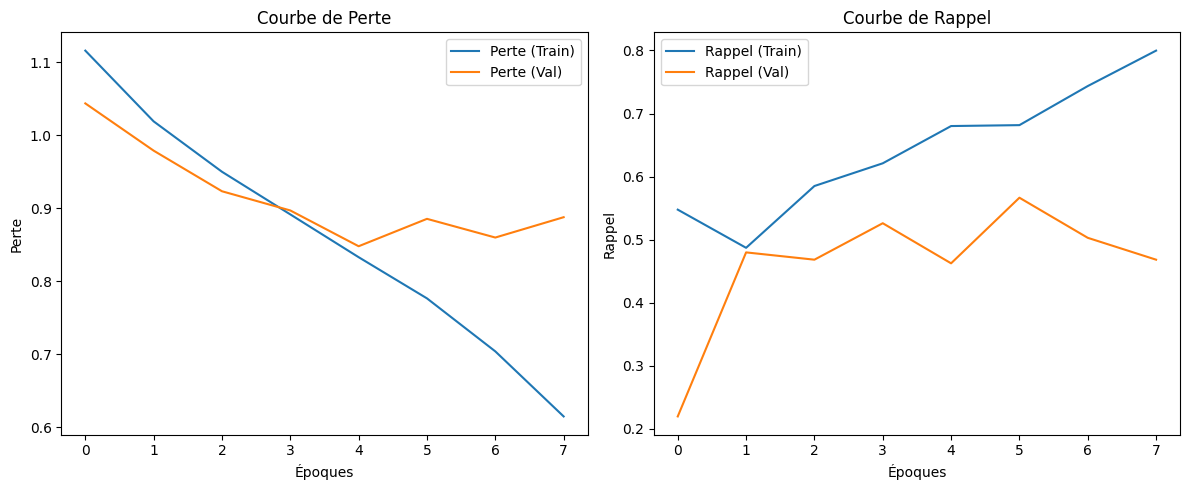

Modèle sauvegardé sous 'lstm_sarcasm_model.h5'


In [80]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import precision_recall_curve, f1_score
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
## 6. Construction du Modèle LSTM
# ==========================================================
print("--- Construction du modèle LSTM ---")
model = Sequential()

# 1. Couche d'Embedding (MODIFIÉE)
# On utilise 'weights' pour charger nos poids GloVe
# On met 'trainable=False' pour  geler les poids de GLoVe

model.add(Embedding(
    input_dim=num_words_in_vocab,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix], # On charge la matrice GloVe
    input_length=MAX_SEQUENCE_LENGTH,
    trainable=True,            # On gèle les poids GloVe
    mask_zero=True
))

model.add(Bidirectional(LSTM(64,kernel_regularizer=l2(0.001), # Pénalise les poids de la couche
                             recurrent_regularizer=l2(0.001)
                              # Pénalise les poids de la récurrence
                            ))) 
model.add(Dropout(0.4))
model.add(Dense(32, activation='relu' , kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid')) # Sortie binaire

# ==========================================================
## 7. Gestion du Déséquilibre et Compilation
# ==========================================================

# Calcul des poids de classe
weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
class_weight = {i : weights[i] for i in range(len(weights))}
print(f"Poids des classes (gestion déséquilibre) : {class_weight}")

# Optimiseur avec un taux d'apprentissage plus faible
#un learning rate plus bas est souvent bon avec GloVe
mon_optimiseur = Adam(learning_rate=0.0005)

model.compile(
    loss='binary_crossentropy',
    optimizer=mon_optimiseur,
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'), 
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

# ==========================================================
## 8. Entraînement du Modèle
# ==========================================================
print("--- Démarrage de l'entraînement ---")
EPOCHS = 8
BATCH_SIZE = 64


# --- NOUVEAU : Ajout des Callbacks ---
# On surveille la métrique de validation 'val_recall' (cruciale pour
# la classe déséquilibrée) ou 'val_loss' (plus stable)
early_stopping = EarlyStopping(
    monitor='val_recall', # ou 'val_loss'
    patience=5,             # Nb d'époques sans amélioration avant d'arrêter
    mode='max',             # 'max' pour recall/accuracy, 'min' pour loss
    verbose=1,
    restore_best_weights=True # Restaure les poids du meilleur epoch
)

# Sauvegarde le meilleur modèle
model_checkpoint = ModelCheckpoint(
    'best_lstm_sarcasm_model.h5', # Nouveau nom pour le meilleur modèle
    monitor='val_recall', # Doit être la même métrique que EarlyStopping car Keras ne calcule pas un F1 fiable en live.
    mode='max',
    save_best_only=True,
    verbose=1
)


history = model.fit(
    X_train_padded,
    y_train_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val_np),
    class_weight=class_weight, # Application des poids
    verbose=1,
    callbacks=[early_stopping, model_checkpoint] # : Ajout des callbacks
)
print("--- Entraînement terminé  (meilleurs poids restaurés)---")

# ==========================================================
## 9. Analysez des courbes d'apprentissage
# ==========================================================

print("---Analysez des courbes d'apprentissage---")



# Fonction pour afficher les courbes
def plot_history(history):
    # --- Graphique de la Perte (Loss) ---
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Perte (Train)')
    plt.plot(history.history['val_loss'], label='Perte (Val)')
    plt.title('Courbe de Perte')
    plt.xlabel('Époques')
    plt.ylabel('Perte')
    plt.legend()

    # --- Graphique du Rappel (Recall) ---
    # (Puisque vous surveillez val_recall, regardons-le)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['recall'], label='Rappel (Train)')
    plt.plot(history.history['val_recall'], label='Rappel (Val)')
    plt.title('Courbe de Rappel')
    plt.xlabel('Époques')
    plt.ylabel('Rappel')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Appelez la fonction avec votre historique
plot_history(history)

model.save('lstm_sarcasm_model.h5')
print("Modèle sauvegardé sous 'lstm_sarcasm_model.h5'")



--- Évaluation du modèle ---
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Meilleur seuil trouvé : 0.3965 (F1-score: 0.4127)

--- Rapport de Classification (Seuil 0.5 par défaut) ---
                     precision    recall  f1-score   support

Non-Sarcastique (0)       0.79      0.53      0.63       521
    Sarcastique (1)       0.29      0.57      0.38       173

           accuracy                           0.54       694
          macro avg       0.54      0.55      0.51       694
       weighted avg       0.66      0.54      0.57       694


--- Rapport de Classification (Seuil optimisé) ---
                     precision    recall  f1-score   support

Non-Sarcastique (0)       0.82      0.28      0.41       521
    Sarcastique (1)       0.27      0.82      0.41       173

           accuracy                           0.41       694
          macro avg       0.55      0.55      0.41       694
       weighted avg       0.69      0.41      0.41       694


 Performance du modèle LSTM (Bas

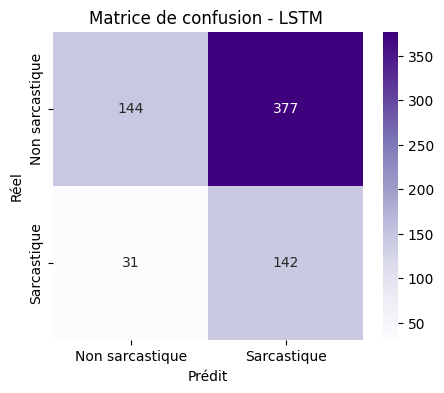


Analyse de la Matrice de Confusion :
Vrais Négatifs (TN): 144 (Prédit 'Non Sarcastique' et c'était correct)
Faux Positifs (FP): 377 (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')
Faux Négatifs (FN): 31 (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')
Vrais Positifs (TP): 142 (Prédit 'Sarcastique' et c'était correct)


In [81]:
# ==========================================================
## 10. Évaluation du Modèle
# ==========================================================
print("--- Évaluation du modèle ---")


# --- 2. Prédictions et Rapport de Classification ---
'''y_pred_probs = model.predict(X_val_padded)
y_pred_classes = (y_pred_probs > 0.5).astype(int) # Seuil de 0.5

print("\n--- Rapport de Classification (Validation) pour LSTM ---")
print(classification_report(y_val_np, y_pred_classes, target_names=['Non-Sarcastique (0)', 'Sarcastique (1)']))'''"LSTM_seed - Copy.ipynb"




# --- 2.1. Prédictions (Probabilités) ---
y_pred_probs = model.predict(X_val_padded).ravel() # .ravel() pour aplatir

# --- 2.2. Trouver le meilleur seuil ---
# Calcule Précision, Rappel pour différents seuils
precision, recall, thresholds = precision_recall_curve(y_val_np, y_pred_probs)
# Calcule F1-score pour chaque seuil (sauf le dernier)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-9) # 1e-9 évite division / 0

# Trouver l'index du meilleur F1-score
best_f1_idx = np.argmax(f1_scores)
best_f1 = f1_scores[best_f1_idx]
best_threshold = thresholds[best_f1_idx]

print(f"Meilleur seuil trouvé : {best_threshold:.4f} (F1-score: {best_f1:.4f})")

# --- 3. Appliquer le meilleur seuil pour le rapport de classification ---
y_pred_classes_optim = (y_pred_probs > best_threshold).astype(int)

print("\n--- Rapport de Classification (Seuil 0.5 par défaut) ---")
print(classification_report(y_val_np, (y_pred_probs > 0.5).astype(int), target_names=['Non-Sarcastique (0)', 'Sarcastique (1)']))

print("\n--- Rapport de Classification (Seuil optimisé) ---")
print(classification_report(y_val_np, y_pred_classes_optim, target_names=['Non-Sarcastique (0)', 'Sarcastique (1)']))



# Évaluation complète
acc = accuracy_score(y_val_np, y_pred_classes_optim)
prec = precision_score(y_val_np, y_pred_classes_optim)
rec = recall_score(y_val_np, y_pred_classes_optim)
f1 = f1_score(y_val_np, y_pred_classes_optim)

print("\n Performance du modèle LSTM (Base) : ")
print(f"Accuracy  : {acc:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")



# Matrice de confusion 
cm = confusion_matrix(y_val_np, y_pred_classes_optim)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Non sarcastique", "Sarcastique"],
            yticklabels=["Non sarcastique", "Sarcastique"])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - LSTM ")
plt.show()

print("\nAnalyse de la Matrice de Confusion :")
print(f"Vrais Négatifs (TN): {cm[0][0]} (Prédit 'Non Sarcastique' et c'était correct)")
print(f"Faux Positifs (FP): {cm[0][1]} (Prédit 'Sarcastique' mais c'était 'Non Sarcastique')")
print(f"Faux Négatifs (FN): {cm[1][0]} (Prédit 'Non Sarcastique' mais c'était 'Sarcastique')")
print(f"Vrais Positifs (TP): {cm[1][1]} (Prédit 'Sarcastique' et c'était correct)")





 F1-score de 0.41 est donc bien le score du meilleur modèle trouvé avant que le sur-apprentissage ne devienne un problème .
en effet:
 Résultat est Protégé : Grâce à EarlyStopping(..., restore_best_weights=True), le modèle que le modele évalué à la fin n'était pas le modèle sur-appris de l'époque 10. Keras a automatiquement rechargé le "meilleur" modèle (celui de l'époque 5 ou 6).

Le fait que vous deviez choisir entre val_loss (qui casse F0) et val_recall (qui est instable) le que votre modèle actuel est à sa limite.


## 4. Comparaison et sélection du meilleur modèle

Calcul des AUC — BERT & LSTM

In [93]:
print("\n=== CALCUL DES AUC POUR LES MODÈLES DEEP LEARNING ===")

from sklearn.metrics import roc_auc_score, roc_curve, auc
import torch.nn.functional as F
import torch
import numpy as np

#  AUC pour BERT
try:
    preds_output_bert = trainer.predict(val_dataset)
    logits_bert = torch.tensor(preds_output_bert.predictions)

    # Probabilité de la classe 1 ("sarcastique")
    probs_bert = F.softmax(logits_bert, dim=-1).numpy()[:, 1]

    auc_bert = roc_auc_score(y_val, probs_bert)
    print(f" AUC BERT : {auc_bert:.4f}")

except Exception as e:
    print(" BERT indisponible :", e)
    auc_bert = None

#  AUC pour LSTM

try:
    # LSTM sort des probabilités
    probs_lstm_all = model_lstm.predict(X_val_padded)

    # Si sortie de forme (N,1)
    if probs_lstm_all.shape[-1] == 1:
        probs_lstm = probs_lstm_all.ravel()
    else:
        probs_lstm = probs_lstm_all[:, 1]

    auc_lstm = roc_auc_score(y_val, probs_lstm)
    print(f" AUC LSTM : {auc_lstm:.4f}")

except Exception as e:
    print(" LSTM indisponible :", e)
    auc_lstm = None




=== CALCUL DES AUC POUR LES MODÈLES DEEP LEARNING ===


c:\Python310-64bit\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 AUC BERT : 0.6642
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
 AUC LSTM : 0.5687


Tracé des courbes ROC (BERT + LSTM)

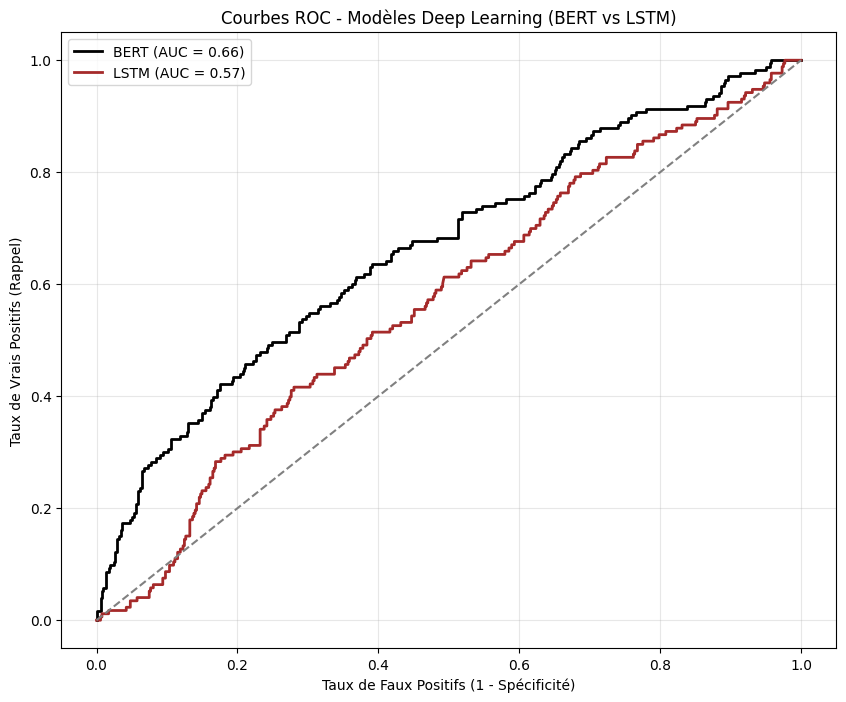

In [94]:
plt.figure(figsize=(10, 8))

def plot_roc(y_true, y_probs, label, color):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{label} (AUC = {roc_auc:.2f})")

# BERT
if auc_bert is not None:
    plot_roc(y_val, probs_bert, "BERT", "black")

# LSTM
if auc_lstm is not None:
    plot_roc(y_val, probs_lstm, "LSTM", "brown")

# Ligne du hasard
plt.plot([0,1],[0,1],"--",color="gray")

plt.xlabel("Taux de Faux Positifs (1 - Spécificité)")
plt.ylabel("Taux de Vrais Positifs (Rappel)")
plt.title("Courbes ROC - Modèles Deep Learning (BERT vs LSTM)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Tableau comparatif Deep Learning

In [95]:
import pandas as pd

resultats_dl = [
    {
        "Modèle": "BERT",
        "Vectorisation": "Embeddings (Transformer)",
        "Accuracy": 0.7205,
        "Précision": 0.4371,
        "Rappel": 0.4220,
        "F1-Score": 0.4294,
        "AUC": 0.66
    },
    {
        "Modèle": "LSTM",
        "Vectorisation": "Word Embeddings",
        "Accuracy": 0.4121,
        "Précision": 0.2736,
        "Rappel": 0.8208,
        "F1-Score": 0.4104,
        "AUC": 0.57
    }
]

df_dl = pd.DataFrame(resultats_dl).round(4)
df_dl = df_dl.sort_values(by="F1-Score", ascending=False)

print("\n TABLEAU COMPARATIF FINAL (DEEP LEARNING) ")
display(df_dl)



 TABLEAU COMPARATIF FINAL (DEEP LEARNING) 


,Modèle,Vectorisation,Accuracy,Précision,Rappel,F1-Score,AUC
0,BERT,Embeddings (Transformer),0.7205,0.4371,0.4220,0.4294,0.66
1,LSTM,Word Embeddings,0.4121,0.2736,0.8208,0.4104,0.57


## 5. Test final et sauvegarde

✔ Modèle BERT chargé


c:\Python310-64bit\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



=== Résultat Final BERT ===
Accuracy : 0.8421
Precision: 0.3735
Recall   : 0.1550
F1-score : 0.2191
AUC      : 0.6497

--- Rapport complet ---
                 precision    recall  f1-score   support

Non sarcastique       0.87      0.96      0.91      1200
    Sarcastique       0.37      0.15      0.22       200

       accuracy                           0.84      1400
      macro avg       0.62      0.56      0.57      1400
   weighted avg       0.80      0.84      0.81      1400



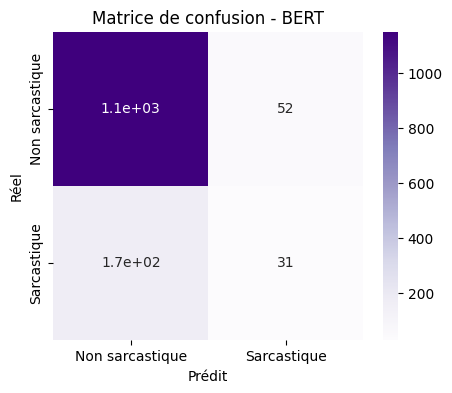

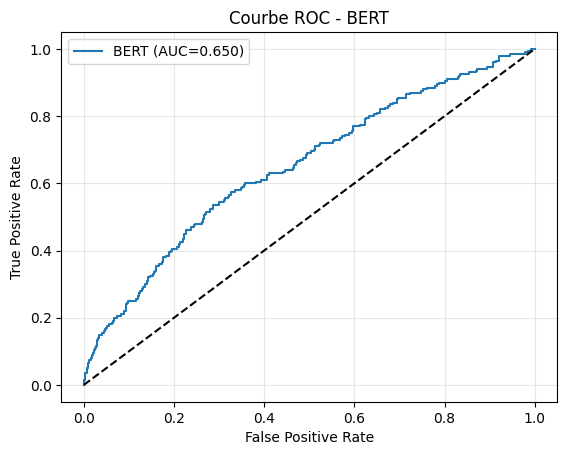


✔ Fichier 'final_BERT_predictions.csv' sauvegardé.


In [96]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import BertTokenizerFast, BertForSequenceClassification, Trainer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# ============================
# 1. Charger modèle + tokenizer
# ============================
model = BertForSequenceClassification.from_pretrained("bert_sarcasm_model")
tokenizer = BertTokenizerFast.from_pretrained("bert_sarcasm_model")

print("✔ Modèle BERT chargé")

# ============================
# 2. Charger le jeu de test
# ============================
test_df = pd.read_csv("task_A_En_test.csv")

assert "text" in test_df.columns
assert "sarcastic" in test_df.columns

# Nettoyage
test_df["text_clean"] = test_df["text"].apply(cleanText)

# ============================
# 3. Tokenisation BERT
# ============================
encodings = tokenizer(
    test_df["text_clean"].tolist(),
    truncation=True,
    padding=True,
    max_length=64,
    return_tensors="pt"
)

labels = torch.tensor(test_df["sarcastic"].values)

# ============================
# 4. Préparation dataset BERT
# ============================
class BERTDataset(torch.utils.data.Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = labels

    def __getitem__(self, idx):
        return {
            "input_ids": self.enc["input_ids"][idx],
            "attention_mask": self.enc["attention_mask"][idx],
            "labels": self.labels[idx]
        }

    def __len__(self):
        return len(self.labels)

test_dataset = BERTDataset(encodings, labels)

# Charger Trainer
trainer = Trainer(model=model)

# ============================
# 5. Prédictions BERT
# ============================
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()  # proba sarcastique
y_pred = np.argmax(logits, axis=1)
y_test = test_df["sarcastic"].values

# ============================
# 6. Métriques finales
# ============================
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, probs)

print("\n=== Résultat Final BERT ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\n--- Rapport complet ---")
print(classification_report(
    y_test, y_pred,
    target_names=["Non sarcastique", "Sarcastique"]
))

# ============================
# 7. Matrice de confusion
# ============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Purples",
            xticklabels=["Non sarcastique","Sarcastique"],
            yticklabels=["Non sarcastique","Sarcastique"])
plt.title("Matrice de confusion - BERT")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# ============================
# 8. Courbe ROC
# ============================
fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label=f"BERT (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - BERT")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================
# 9. Sauvegarde des prédictions
# ============================
test_df["prediction"] = y_pred
test_df[["text", "prediction"]].to_csv("final_BERT_predictions.csv", index=False)

print("\n✔ Fichier 'final_BERT_predictions.csv' sauvegardé.")
